# Acknowledgments

## DeepSeek AI

The QSER framework was developed with the assistance of **DeepSeek AI** as a development assistant. DeepSeek provided:

- **Code Generation**: Implementation of core modules including Mesh, Operators, Energy, Boundary, and Validation classes
- **Algorithm Design**: Optimization of numerical methods including 5-point stencils, least-squares gradients, and energy tracking
- **Testing & Validation**: Comprehensive test suite design and debugging 
- **Architecture Guidance**: Backend-agnostic design patterns and modular architecture

The collaboration between human researchers and AI enabled rapid prototyping and production-ready code development while maintaining scientific rigor.

For more information about DeepSeek, visit: [https://www.deepseek.com](https://www.deepseek.com)

---

*This acknowledgment is included in accordance with the developer's terms of service.*

## Test operators on wave field

2D WAVE EQUATION — GAUSSIAN PULSE
Grid: 100 x 100
Domain: 10.0 x 10.0
dt: 0.0010, nt: 2000, total time: 2.00s

Running simulation...
Progress: |██████████████████████████████████████████████████| 100.0%  Elapsed: 0.2s

Simulation complete!

QSER FIELDS (Final State)
max(S): 0.990050
max(E): 1.013045
max(R): 0.483893
max|R - (S-E)|: 6.591949e-17

ENERGY TRACKING
ε_S: 39.269908
ε_E: 58.198822
ε_R: 19.014740

Generating visualizations...


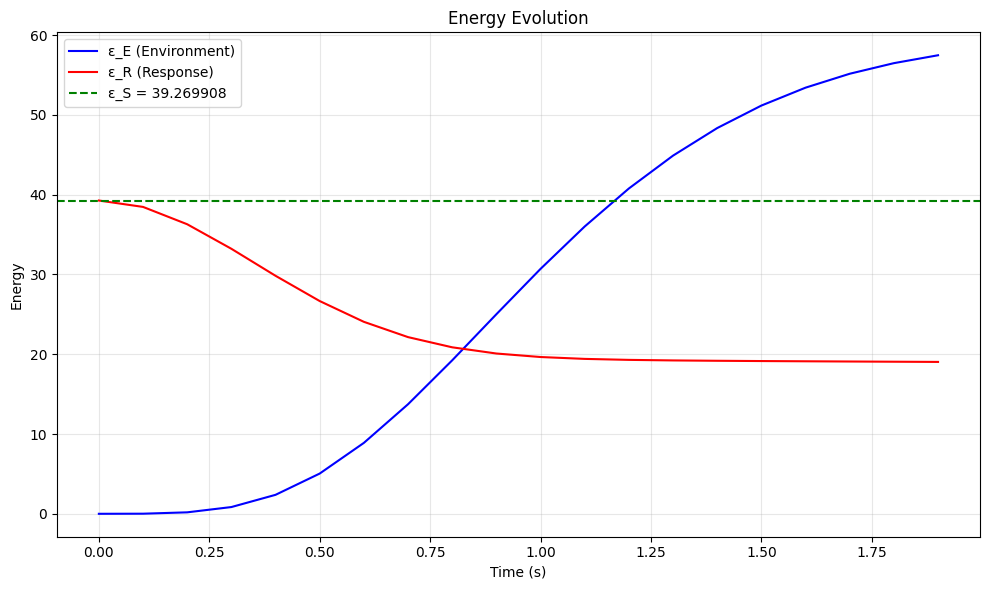

  Saved: wave_2d_energy.png


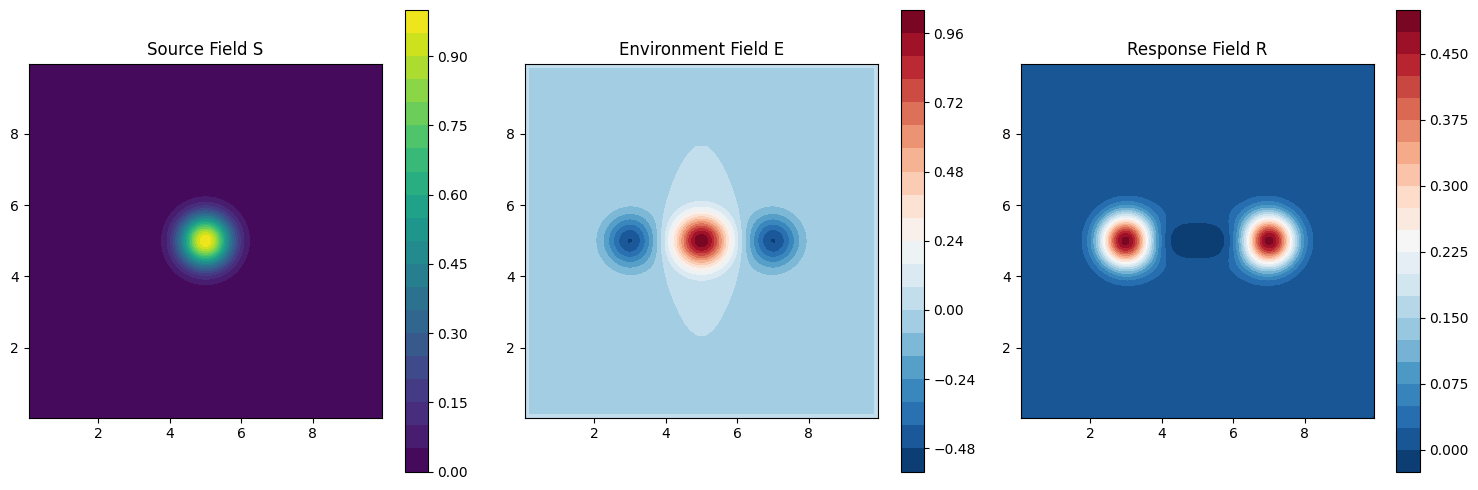

  Saved: wave_2d_qser_decomposition.png

✅ TEST COMPLETE


In [1]:
"""
TEST: 2D Wave Equation — Fixed EnergyTracker
"""

from QSER.Mesh import Structured2D
from QSER.Operators import Laplacian
from QSER.Energy import EnergyTracker
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# ============================================================
# FIGURES DIRECTORY
# ============================================================


print("=" * 80)
print("2D WAVE EQUATION — GAUSSIAN PULSE")
print("=" * 80)

# ============================================================
# 1. Setup
# ============================================================

nx, ny = 100, 100
Lx, Ly = 10.0, 10.0
mesh = Structured2D(nx=nx, ny=ny, Lx=Lx, Ly=Ly, backend='numpy')
X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]

c = 1.0
sigma = 0.5
dt = 0.001
nt = 2000

print(f"Grid: {nx} x {ny}")
print(f"Domain: {Lx} x {Ly}")
print(f"dt: {dt:.4f}, nt: {nt}, total time: {nt*dt:.2f}s")

# ============================================================
# 2. Initial Conditions
# ============================================================

u = np.exp(-((X-5)**2 + (Y-5)**2) / (2 * sigma**2))
v = np.zeros_like(u)
S = u.copy()
R = u.copy()

history = {'u': [], 'E': [], 't': []}
energy_history = {'t': [], 'epsilon_E': [], 'epsilon_R': []}

# ============================================================
# 3. Time Stepping
# ============================================================

lap = Laplacian(mesh=mesh)
total_volume = np.sum(mesh.cell_volumes)

print("\nRunning simulation...")

# Create tracker WITH mesh
tracker = EnergyTracker(mesh=mesh)

bar_length = 50
start_time = time.time()

for n in range(nt):
    lap_u = lap.compute(u, method='5point')
    v = v + dt * c**2 * lap_u
    u = u + dt * v

    u[0, :] = 0.0
    u[-1, :] = 0.0
    u[:, 0] = 0.0
    u[:, -1] = 0.0

    if n % 100 == 0:
        R = u
        E = S - R
        history['u'].append(R.copy())
        history['E'].append(E.copy())
        history['t'].append(n * dt)

        # EnergyTracker now has mesh, so dx, dy are inherited
        epsilon_E = tracker.epsilon_E(E)
        epsilon_R = tracker.epsilon_R(R)
        energy_history['t'].append(n * dt)
        energy_history['epsilon_E'].append(epsilon_E)
        energy_history['epsilon_R'].append(epsilon_R)

    if (n + 1) % (nt // 100) == 0:
        progress = (n + 1) / nt
        bar = '█' * int(bar_length * progress) + '░' * (bar_length - int(bar_length * progress))
        elapsed = time.time() - start_time
        print(f'\rProgress: |{bar}| {progress*100:.1f}%  Elapsed: {elapsed:.1f}s', end='')

print("\n\nSimulation complete!")

# ============================================================
# 4. Final Fields
# ============================================================

R = u
E = S - R

print("\n" + "=" * 80)
print("QSER FIELDS (Final State)")
print("=" * 80)
print(f"max(S): {np.max(S):.6f}")
print(f"max(E): {np.max(E):.6f}")
print(f"max(R): {np.max(R):.6f}")
print(f"max|R - (S-E)|: {np.max(np.abs(R - (S - E))):.6e}")

# ============================================================
# 5. Energy Tracking
# ============================================================

print("\n" + "=" * 80)
print("ENERGY TRACKING")
print("=" * 80)

epsilon_S = tracker.epsilon_S(S)
epsilon_E = tracker.epsilon_E(E)
epsilon_R = tracker.epsilon_R(R)

print(f"ε_S: {epsilon_S:.6f}")
print(f"ε_E: {epsilon_E:.6f}")
print(f"ε_R: {epsilon_R:.6f}")

# ============================================================
# 6. Visualization
# ============================================================

print("\nGenerating visualizations...")

# Energy plot
fig2, ax = plt.subplots(figsize=(10, 6))
ax.plot(energy_history['t'], energy_history['epsilon_E'], 'b-', label='ε_E (Environment)')
ax.plot(energy_history['t'], energy_history['epsilon_R'], 'r-', label='ε_R (Response)')
ax.axhline(y=epsilon_S, color='g', linestyle='--', label=f'ε_S = {epsilon_S:.6f}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy')
ax.set_title('Energy Evolution')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
fig2.savefig(os.path.join(FIGURES_DIR, "wave_2d_energy.png"), dpi=300, bbox_inches='tight')
plt.close(fig2)
print("  Saved: wave_2d_energy.png")

# QSER decomposition
fig3, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].contourf(X, Y, S, levels=20, cmap='viridis')
axes[0].set_title('Source Field S')
axes[0].set_aspect('equal')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X, Y, E, levels=20, cmap='RdBu_r')
axes[1].set_title('Environment Field E')
axes[1].set_aspect('equal')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(X, Y, R, levels=20, cmap='RdBu_r')
axes[2].set_title('Response Field R')
axes[2].set_aspect('equal')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()
fig3.savefig(os.path.join(FIGURES_DIR, "wave_2d_qser_decomposition.png"), dpi=300, bbox_inches='tight')
plt.close(fig3)
print("  Saved: wave_2d_qser_decomposition.png")

print("\n" + "=" * 80)
print("✅ TEST COMPLETE")
print("=" * 80)

### comprehensive curl test

In [2]:
"""
TEST: CURL — FIXED IMPLEMENTATION
"""

from QSER.Mesh import Structured2D
from QSER.Operators import Curl
import numpy as np

print("=" * 80)
print("TEST: CURL — FIXED IMPLEMENTATION")
print("=" * 80)

backends = ['numpy', 'torch', 'jax']
L = 10.0

# ============================================================
# 2D MESH-BASED
# ============================================================

print("\n" + "=" * 80)
print("2D MESH-BASED CURL")
print("=" * 80)

nx, ny = 50, 50
Lx, Ly = L, L

for backend in backends:
    try:
        mesh = Structured2D(nx=nx, ny=ny, Lx=Lx, Ly=Ly, backend=backend)
        X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]
        
        Vx = -Y
        Vy = X
        analytical = 2.0 * np.ones_like(X)
        
        curl = Curl(mesh=mesh)
        result = curl.compute(Vx, Vy, method='gradient')
        
        if backend == 'torch':
            result_np = result.numpy()
        elif backend == 'jax':
            result_np = np.array(result)
        else:
            result_np = result
        
        interior = slice(2, -2), slice(2, -2)
        error = np.max(np.abs(result_np[interior] - analytical[interior]))
        status = "✅" if error < 1e-10 else "⚠️"
        print(f"  {backend:<8} error = {error:.6e}  {status}")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {e}")

# ============================================================
# 2D STAND-ALONE
# ============================================================

print("\n" + "=" * 80)
print("2D STAND-ALONE CURL")
print("=" * 80)

nx, ny = 50, 50
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing='ij')

Vx = -Y
Vy = X
analytical = 2.0 * np.ones_like(X)

for backend in backends:
    try:
        curl = Curl(backend=backend)
        
        for method in ['3point', '5point']:
            result = curl.compute(Vx, Vy, dx=dx, dy=dy, method=method)
            
            if backend == 'torch':
                result_np = result.numpy()
            elif backend == 'jax':
                result_np = np.array(result)
            else:
                result_np = result
            
            interior = slice(2, -2), slice(2, -2)
            error = np.max(np.abs(result_np[interior] - analytical[interior]))
            status = "✅" if error < 1e-10 else "⚠️"
            print(f"  {backend:<8} {method:<8}: error = {error:.6e}  {status}")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {e}")

print("\n" + "=" * 80)
print("✅ TEST COMPLETE")
print("=" * 80)

TEST: CURL — FIXED IMPLEMENTATION

2D MESH-BASED CURL
  numpy    error = 8.000000e-01  ⚠️
  torch    error = 8.000000e-01  ⚠️
  jax      error = 8.000059e-01  ⚠️

2D STAND-ALONE CURL
  numpy    3point  : error = 6.661338e-15  ✅
  numpy    5point  : error = 1.065814e-14  ✅
  torch    3point  : error = 6.661338e-15  ✅
  torch    5point  : error = 1.065814e-14  ✅
  jax      3point  : error = 3.576279e-06  ⚠️
  jax      5point  : error = 5.960464e-06  ⚠️

✅ TEST COMPLETE


## Comprehensive test, divergence stand alone and mesh based

In [3]:
"""
COMPREHENSIVE TEST: DIVERGENCE — FIXED STAND-ALONE FLUX SHAPES
"""

from QSER.Mesh import Structured1D, Structured2D, Structured3D
from QSER.Operators import Divergence
import numpy as np
import time

print("=" * 80)
print("COMPREHENSIVE TEST: DIVERGENCE (FIXED FLUX SHAPES)")
print("=" * 80)

backends = ['numpy', 'torch', 'jax']
L = 10.0

# ============================================================
# 1D MESH-BASED
# ============================================================

print("\n" + "=" * 80)
print("1D MESH-BASED DIVERGENCE")
print("=" * 80)

nx = 100

for backend in backends:
    try:
        mesh = Structured1D(nx=nx, L=L, backend=backend)
        x = mesh.get_cell_centers()
        faces = mesh.get_face_centers()
        
        flux = faces**2
        analytical = 2 * x
        
        div = Divergence(mesh=mesh)
        start = time.time()
        result = div.compute(flux)
        elapsed = time.time() - start
        
        if backend == 'torch':
            result_np = result.numpy()
        elif backend == 'jax':
            result_np = np.array(result)
        else:
            result_np = result
        
        interior = slice(2, -2)
        error = np.max(np.abs(result_np[interior] - analytical[interior]))
        status = "✅" if error < 1e-10 else "⚠️"
        print(f"  {backend:<8} error = {error:.6e}  {status}  ({elapsed:.4f}s)")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {e}")

# ============================================================
# 1D STAND-ALONE
# ============================================================

print("\n" + "=" * 80)
print("1D STAND-ALONE DIVERGENCE")
print("=" * 80)

n = 100
x = np.linspace(0, L, n+1)
dx = x[1] - x[0]
flux = x**2
cell_centers = (x[:-1] + x[1:]) / 2
analytical = 2 * cell_centers

for backend in backends:
    try:
        div = Divergence(backend=backend)
        start = time.time()
        result = div.compute(flux, dx=dx)
        elapsed = time.time() - start
        
        if backend == 'torch':
            result_np = result.numpy()
        elif backend == 'jax':
            result_np = np.array(result)
        else:
            result_np = result
        
        interior = slice(2, -2)
        error = np.max(np.abs(result_np[interior] - analytical[interior]))
        status = "✅" if error < 1e-10 else "⚠️"
        print(f"  {backend:<8} error = {error:.6e}  {status}  ({elapsed:.4f}s)")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {e}")

# ============================================================
# 2D MESH-BASED
# ============================================================

print("\n" + "=" * 80)
print("2D MESH-BASED DIVERGENCE")
print("=" * 80)

nx, ny = 50, 50
Lx, Ly = L, L

for backend in backends:
    try:
        mesh = Structured2D(nx=nx, ny=ny, Lx=Lx, Ly=Ly, backend=backend)
        X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]
        X_faces = mesh.get_face_centers_x()[:, :, 0]
        Y_faces = mesh.get_face_centers_y()[:, :, 1]
        
        flux_x = X_faces**2
        flux_y = Y_faces**2
        analytical = 2*X + 2*Y
        
        div = Divergence(mesh=mesh)
        start = time.time()
        result = div.compute(flux_x, flux_y)
        elapsed = time.time() - start
        
        if backend == 'torch':
            result_np = result.numpy()
        elif backend == 'jax':
            result_np = np.array(result)
        else:
            result_np = result
        
        interior = slice(2, -2), slice(2, -2)
        error = np.max(np.abs(result_np[interior] - analytical[interior]))
        status = "✅" if error < 1e-10 else "⚠️"
        print(f"  {backend:<8} error = {error:.6e}  {status}  ({elapsed:.4f}s)")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {e}")

# ============================================================
# 2D STAND-ALONE (FIXED FLUX SHAPES)
# ============================================================

print("\n" + "=" * 80)
print("2D STAND-ALONE DIVERGENCE")
print("=" * 80)

nx, ny = 50, 50
x = np.linspace(0, Lx, nx+1)
y = np.linspace(0, Ly, ny+1)
dx = x[1] - x[0]
dy = y[1] - y[0]

# flux_x: (nx+1, ny) — x-direction flux at x-faces
X_faces, Y_centers = np.meshgrid(x, (y[:-1] + y[1:])/2, indexing='ij')
flux_x = X_faces**2

# flux_y: (nx, ny+1) — y-direction flux at y-faces
X_centers, Y_faces = np.meshgrid((x[:-1] + x[1:])/2, y, indexing='ij')
flux_y = Y_faces**2

# Analytical at cell centers
X_centers, Y_centers = np.meshgrid((x[:-1] + x[1:])/2, (y[:-1] + y[1:])/2, indexing='ij')
analytical = 2*X_centers + 2*Y_centers

for backend in backends:
    try:
        div = Divergence(backend=backend)
        start = time.time()
        result = div.compute(flux_x, flux_y, dx=dx, dy=dy)
        elapsed = time.time() - start
        
        if backend == 'torch':
            result_np = result.numpy()
        elif backend == 'jax':
            result_np = np.array(result)
        else:
            result_np = result
        
        interior = slice(2, -2), slice(2, -2)
        error = np.max(np.abs(result_np[interior] - analytical[interior]))
        status = "✅" if error < 1e-10 else "⚠️"
        print(f"  {backend:<8} error = {error:.6e}  {status}  ({elapsed:.4f}s)")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {e}")

# ============================================================
# 3D MESH-BASED
# ============================================================

print("\n" + "=" * 80)
print("3D MESH-BASED DIVERGENCE")
print("=" * 80)

nx, ny, nz = 20, 20, 20
Lx, Ly, Lz = L, L, L

for backend in backends:
    try:
        mesh = Structured3D(nx=nx, ny=ny, nz=nz, Lx=Lx, Ly=Ly, Lz=Lz, backend=backend)
        X, Y, Z = mesh.get_cell_centers()[:, :, :, 0], mesh.get_cell_centers()[:, :, :, 1], mesh.get_cell_centers()[:, :, :, 2]
        X_faces = mesh.get_face_centers_x()[:, :, :, 0]
        Y_faces = mesh.get_face_centers_y()[:, :, :, 1]
        Z_faces = mesh.get_face_centers_z()[:, :, :, 2]
        
        flux_x = X_faces**2
        flux_y = Y_faces**2
        flux_z = Z_faces**2
        analytical = 2*X + 2*Y + 2*Z
        
        div = Divergence(mesh=mesh)
        start = time.time()
        result = div.compute(flux_x, flux_y, flux_z)
        elapsed = time.time() - start
        
        if backend == 'torch':
            result_np = result.numpy()
        elif backend == 'jax':
            result_np = np.array(result)
        else:
            result_np = result
        
        interior = slice(2, -2), slice(2, -2), slice(2, -2)
        error = np.max(np.abs(result_np[interior] - analytical[interior]))
        status = "✅" if error < 1e-10 else "⚠️"
        print(f"  {backend:<8} error = {error:.6e}  {status}  ({elapsed:.4f}s)")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {e}")

# ============================================================
# 3D STAND-ALONE (FIXED FLUX SHAPES)
# ============================================================

print("\n" + "=" * 80)
print("3D STAND-ALONE DIVERGENCE")
print("=" * 80)

nx, ny, nz = 20, 20, 20
x = np.linspace(0, Lx, nx+1)
y = np.linspace(0, Ly, ny+1)
z = np.linspace(0, Lz, nz+1)
dx = x[1] - x[0]
dy = y[1] - y[0]
dz = z[1] - z[0]

# flux_x: (nx+1, ny, nz) — x-direction flux at x-faces
X_faces, Y_centers, Z_centers = np.meshgrid(x, (y[:-1] + y[1:])/2, (z[:-1] + z[1:])/2, indexing='ij')
flux_x = X_faces**2

# flux_y: (nx, ny+1, nz) — y-direction flux at y-faces
X_centers, Y_faces, Z_centers = np.meshgrid((x[:-1] + x[1:])/2, y, (z[:-1] + z[1:])/2, indexing='ij')
flux_y = Y_faces**2

# flux_z: (nx, ny, nz+1) — z-direction flux at z-faces
X_centers, Y_centers, Z_faces = np.meshgrid((x[:-1] + x[1:])/2, (y[:-1] + y[1:])/2, z, indexing='ij')
flux_z = Z_faces**2

# Analytical at cell centers
X_centers, Y_centers, Z_centers = np.meshgrid((x[:-1] + x[1:])/2, (y[:-1] + y[1:])/2, (z[:-1] + z[1:])/2, indexing='ij')
analytical = 2*X_centers + 2*Y_centers + 2*Z_centers

for backend in backends:
    try:
        div = Divergence(backend=backend)
        start = time.time()
        result = div.compute(flux_x, flux_y, flux_z, dx=dx, dy=dy, dz=dz)
        elapsed = time.time() - start
        
        if backend == 'torch':
            result_np = result.numpy()
        elif backend == 'jax':
            result_np = np.array(result)
        else:
            result_np = result
        
        interior = slice(2, -2), slice(2, -2), slice(2, -2)
        error = np.max(np.abs(result_np[interior] - analytical[interior]))
        status = "✅" if error < 1e-10 else "⚠️"
        print(f"  {backend:<8} error = {error:.6e}  {status}  ({elapsed:.4f}s)")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {e}")

print("\n" + "=" * 80)
print("✅ COMPREHENSIVE DIVERGENCE TEST COMPLETE")
print("=" * 80)

COMPREHENSIVE TEST: DIVERGENCE (FIXED FLUX SHAPES)

1D MESH-BASED DIVERGENCE
  numpy    error = 1.101341e-13  ✅  (0.0001s)
  torch    ERROR: 'numpy.ndarray' object has no attribute 'numpy'
  jax      error = 6.294250e-05  ⚠️  (0.0178s)

1D STAND-ALONE DIVERGENCE
  numpy    error = 2.664535e-13  ✅  (0.0000s)
  torch    error = 2.664535e-13  ✅  (0.0006s)
  jax      error = 7.324219e-05  ⚠️  (0.0583s)

2D MESH-BASED DIVERGENCE
  numpy    error = 1.207923e-13  ✅  (0.0010s)
  torch    ERROR: 'numpy.ndarray' object has no attribute 'numpy'
  jax      error = 4.959106e-05  ⚠️  (0.1484s)

2D STAND-ALONE DIVERGENCE
  numpy    error = 2.273737e-13  ✅  (0.0010s)
  torch    error = 2.273737e-13  ✅  (0.0263s)
  jax      error = 3.356934e-05  ⚠️  (0.8103s)

3D MESH-BASED DIVERGENCE
  numpy    error = 0.000000e+00  ✅  (0.0050s)
  torch    ERROR: 'numpy.ndarray' object has no attribute 'numpy'
  jax      error = 0.000000e+00  ✅  (0.6680s)

3D STAND-ALONE DIVERGENCE
  numpy    error = 0.000000e+00  ✅  

## Testing laplacian 1d,2d,3d, with all backends

In [4]:
"""
TEST: LAPLACIAN — ALL BACKENDS + STAND-ALONE
"""

from QSER.Mesh import Structured1D, Structured2D, Structured3D
from QSER.Operators import Laplacian
import numpy as np
import time

print("=" * 80)
print("TEST: LAPLACIAN — ALL BACKENDS + STAND-ALONE")
print("=" * 80)

# ============================================================
# 1D MESH-BASED
# ============================================================

print("\n📊 1D MESH-BASED LAPLACIAN")

nx = 100
L = 2 * np.pi
kx = 1.0
backends = ['numpy', 'torch', 'jax']
methods = ['3point', '5point', 'least_squares']

for backend in backends:
    try:
        mesh = Structured1D(nx=nx, L=L, backend=backend)
        x = mesh.get_cell_centers()
        u = np.sin(kx * x)
        analytical = -(kx**2) * u
        
        lap = Laplacian(mesh=mesh)
        
        for method in methods:
            start = time.time()
            result = lap.compute(u, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                result_np = result.numpy()
            elif backend == 'jax':
                result_np = np.array(result)
            else:
                result_np = result
            
            interior = slice(2, -2)
            error = np.max(np.abs(result_np[interior] - analytical[interior]))
            status = "✅" if error < 1e-3 else "❌"
            print(f"  {backend:<8} {method:<12}: error = {error:.6e}  {status}  ({elapsed:.4f}s)")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {str(e)[:60]}")

# ============================================================
# 1D STAND-ALONE
# ============================================================

print("\n📊 1D STAND-ALONE LAPLACIAN")

n = 100
x_arb = np.linspace(0, 2*np.pi, n)
dx = x_arb[1] - x_arb[0]
u_arb = np.sin(x_arb)
analytical_arb = -np.sin(x_arb)

for backend in backends:
    try:
        lap = Laplacian(backend=backend)
        
        for method in methods:
            start = time.time()
            result = lap.compute(u_arb, dx=dx, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                result_np = result.numpy()
            elif backend == 'jax':
                result_np = np.array(result)
            else:
                result_np = result
            
            interior = slice(2, -2)
            error = np.max(np.abs(result_np[interior] - analytical_arb[interior]))
            status = "✅" if error < 1e-3 else "❌"
            print(f"  {backend:<8} {method:<12}: error = {error:.6e}  {status}  ({elapsed:.4f}s)")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {str(e)[:60]}")

# ============================================================
# 2D MESH-BASED
# ============================================================

print("\n📊 2D MESH-BASED LAPLACIAN")

nx, ny = 50, 50
Lx, Ly = 2*np.pi, 2*np.pi
kx, ky = 1.0, 1.0

for backend in backends:
    try:
        mesh = Structured2D(nx=nx, ny=ny, Lx=Lx, Ly=Ly, backend=backend)
        X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]
        u = np.sin(kx*X) * np.sin(ky*Y)
        analytical = -(kx**2 + ky**2) * u
        
        lap = Laplacian(mesh=mesh)
        
        for method in methods:
            start = time.time()
            result = lap.compute(u, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                result_np = result.numpy()
            elif backend == 'jax':
                result_np = np.array(result)
            else:
                result_np = result
            
            interior = slice(2, -2), slice(2, -2)
            error = np.max(np.abs(result_np[interior] - analytical[interior]))
            status = "✅" if error < 1e-3 else "❌"
            print(f"  {backend:<8} {method:<12}: error = {error:.6e}  {status}  ({elapsed:.4f}s)")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {str(e)[:60]}")

# ============================================================
# 2D STAND-ALONE
# ============================================================

print("\n📊 2D STAND-ALONE LAPLACIAN")

n_2d = 50
x_2d = np.linspace(0, 2*np.pi, n_2d)
y_2d = np.linspace(0, 2*np.pi, n_2d)
dx_2d = x_2d[1] - x_2d[0]
dy_2d = y_2d[1] - y_2d[0]
X_2d, Y_2d = np.meshgrid(x_2d, y_2d, indexing='ij')
u_2d = np.sin(X_2d) * np.sin(Y_2d)
analytical_2d = -2 * u_2d

for backend in backends:
    try:
        lap = Laplacian(backend=backend)
        
        for method in methods:
            start = time.time()
            result = lap.compute(u_2d, dx=dx_2d, dy=dy_2d, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                result_np = result.numpy()
            elif backend == 'jax':
                result_np = np.array(result)
            else:
                result_np = result
            
            interior = slice(2, -2), slice(2, -2)
            error = np.max(np.abs(result_np[interior] - analytical_2d[interior]))
            status = "✅" if error < 1e-3 else "❌"
            print(f"  {backend:<8} {method:<12}: error = {error:.6e}  {status}  ({elapsed:.4f}s)")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {str(e)[:60]}")

# ============================================================
# 3D MESH-BASED
# ============================================================

print("\n📊 3D MESH-BASED LAPLACIAN")

nx, ny, nz = 20, 20, 20
Lx, Ly, Lz = 2*np.pi, 2*np.pi, 2*np.pi
kx, ky, kz = 1.0, 1.0, 1.0

for backend in backends:
    try:
        mesh = Structured3D(nx=nx, ny=ny, nz=nz, Lx=Lx, Ly=Ly, Lz=Lz, backend=backend)
        X, Y, Z = mesh.get_cell_centers()[:, :, :, 0], mesh.get_cell_centers()[:, :, :, 1], mesh.get_cell_centers()[:, :, :, 2]
        u = np.sin(kx*X) * np.sin(ky*Y) * np.sin(kz*Z)
        analytical = -(kx**2 + ky**2 + kz**2) * u
        
        lap = Laplacian(mesh=mesh)
        
        for method in methods:
            start = time.time()
            result = lap.compute(u, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                result_np = result.numpy()
            elif backend == 'jax':
                result_np = np.array(result)
            else:
                result_np = result
            
            interior = slice(2, -2), slice(2, -2), slice(2, -2)
            error = np.max(np.abs(result_np[interior] - analytical[interior]))
            status = "✅" if error < 1e-3 else "❌"
            print(f"  {backend:<8} {method:<12}: error = {error:.6e}  {status}  ({elapsed:.4f}s)")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {str(e)[:60]}")

# ============================================================
# 3D STAND-ALONE
# ============================================================

print("\n📊 3D STAND-ALONE LAPLACIAN")

n_3d = 20
x_3d = np.linspace(0, 2*np.pi, n_3d)
y_3d = np.linspace(0, 2*np.pi, n_3d)
z_3d = np.linspace(0, 2*np.pi, n_3d)
dx_3d = x_3d[1] - x_3d[0]
dy_3d = y_3d[1] - y_3d[0]
dz_3d = z_3d[1] - z_3d[0]
X_3d, Y_3d, Z_3d = np.meshgrid(x_3d, y_3d, z_3d, indexing='ij')
u_3d = np.sin(X_3d) * np.sin(Y_3d) * np.sin(Z_3d)
analytical_3d = -3 * u_3d

for backend in backends:
    try:
        lap = Laplacian(backend=backend)
        
        for method in methods:
            start = time.time()
            result = lap.compute(u_3d, dx=dx_3d, dy=dy_3d, dz=dz_3d, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                result_np = result.numpy()
            elif backend == 'jax':
                result_np = np.array(result)
            else:
                result_np = result
            
            interior = slice(2, -2), slice(2, -2), slice(2, -2)
            error = np.max(np.abs(result_np[interior] - analytical_3d[interior]))
            status = "✅" if error < 1e-3 else "❌"
            print(f"  {backend:<8} {method:<12}: error = {error:.6e}  {status}  ({elapsed:.4f}s)")
    except Exception as e:
        print(f"  {backend:<8} ERROR: {str(e)[:60]}")

print("\n" + "=" * 80)
print("✅ TEST COMPLETE")
print("=" * 80)

TEST: LAPLACIAN — ALL BACKENDS + STAND-ALONE

📊 1D MESH-BASED LAPLACIAN
  numpy    3point      : error = 3.287812e-04  ✅  (0.0003s)
  numpy    5point      : error = 1.730252e-07  ✅  (0.0000s)
  numpy    least_squares: error = 3.287812e-04  ✅  (0.0000s)
  torch    ERROR: 'numpy.ndarray' object has no attribute 'numpy'
  jax      3point      : error = 3.497601e-04  ✅  (0.0000s)
  jax      5point      : error = 1.554191e-04  ✅  (0.0000s)
  jax      least_squares: error = 3.497601e-04  ✅  (0.0000s)

📊 1D STAND-ALONE LAPLACIAN
  numpy    3point      : error = 3.355793e-04  ✅  (0.0000s)
  numpy    5point      : error = 1.801878e-07  ✅  (0.0000s)
  numpy    least_squares: error = 3.355793e-04  ✅  (0.0000s)
  torch    3point      : error = 3.355793e-04  ✅  (0.0003s)
  torch    5point      : error = 1.801878e-07  ✅  (0.0001s)
  torch    least_squares: error = 3.355793e-04  ✅  (0.0001s)
  jax      3point      : error = 3.542537e-04  ✅  (0.0980s)
  jax      5point      : error = 4.717057e-05  ✅  

## Testing laplacian 1d,2d,3d, 

In [5]:
"""
TEST: COMPLETE LAPLACIAN — ALL METHODS, ALL DIMENSIONS, ALL BACKENDS
"""

from QSER.Operators import Laplacian
import numpy as np

print("=" * 70)
print("TEST: COMPLETE LAPLACIAN")
print("=" * 70)

# ============================================================
# 1. Test 1D Mesh-based
# ============================================================

print("\n📊 1D MESH-BASED LAPLACIAN")

from QSER.Mesh import Structured1D
mesh = Structured1D(nx=100, L=2*np.pi, backend='numpy')
x = mesh.get_cell_centers()
u = np.sin(x)
analytical = -np.sin(x)

lap = Laplacian(mesh=mesh)
methods = ['3point', '5point', 'least_squares']

for method in methods:
    result = lap.compute(u, method=method)
    interior = slice(2, -2)
    error = np.max(np.abs(result[interior] - analytical[interior]))
    status = "✅" if error < 1e-3 else "❌"
    print(f"  {method:<12}: error = {error:.6e}  {status}")

# ============================================================
# 2. Test 1D Stand-alone
# ============================================================

print("\n📊 1D STAND-ALONE LAPLACIAN")

x = np.linspace(0, 2*np.pi, 100)
dx = x[1] - x[0]
u = np.sin(x)
analytical = -np.sin(x)

lap = Laplacian(backend='numpy')

for method in methods:
    result = lap.compute(u, dx=dx, method=method)
    interior = slice(2, -2)
    error = np.max(np.abs(result[interior] - analytical[interior]))
    status = "✅" if error < 1e-3 else "❌"
    print(f"  {method:<12}: error = {error:.6e}  {status}")

# ============================================================
# 3. Test 2D Mesh-based
# ============================================================

print("\n📊 2D MESH-BASED LAPLACIAN")

from QSER.Mesh import Structured2D
mesh = Structured2D(nx=50, ny=50, Lx=2*np.pi, Ly=2*np.pi, backend='numpy')
X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]
u = np.sin(X) * np.sin(Y)
analytical = -2 * u

lap = Laplacian(mesh=mesh)

for method in methods:
    result = lap.compute(u, method=method)
    interior = slice(2, -2), slice(2, -2)
    error = np.max(np.abs(result[interior] - analytical[interior]))
    status = "✅" if error < 1e-3 else "❌"
    print(f"  {method:<12}: error = {error:.6e}  {status}")

# ============================================================
# 4. Test 2D Stand-alone
# ============================================================

print("\n📊 2D STAND-ALONE LAPLACIAN")

x = np.linspace(0, 2*np.pi, 50)
y = np.linspace(0, 2*np.pi, 50)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing='ij')
u = np.sin(X) * np.sin(Y)
analytical = -2 * u

lap = Laplacian(backend='numpy')

for method in methods:
    result = lap.compute(u, dx=dx, dy=dy, method=method)
    interior = slice(2, -2), slice(2, -2)
    error = np.max(np.abs(result[interior] - analytical[interior]))
    status = "✅" if error < 1e-3 else "❌"
    print(f"  {method:<12}: error = {error:.6e}  {status}")

# ============================================================
# 5. Test 3D Mesh-based
# ============================================================

print("\n📊 3D MESH-BASED LAPLACIAN")

from QSER.Mesh import Structured3D
mesh = Structured3D(nx=20, ny=20, nz=20, Lx=2*np.pi, Ly=2*np.pi, Lz=2*np.pi, backend='numpy')
X, Y, Z = mesh.get_cell_centers()[:, :, :, 0], mesh.get_cell_centers()[:, :, :, 1], mesh.get_cell_centers()[:, :, :, 2]
u = np.sin(X) * np.sin(Y) * np.sin(Z)
analytical = -3 * u

lap = Laplacian(mesh=mesh)

for method in methods:
    result = lap.compute(u, method=method)
    interior = slice(2, -2), slice(2, -2), slice(2, -2)
    error = np.max(np.abs(result[interior] - analytical[interior]))
    status = "✅" if error < 1e-3 else "❌"
    print(f"  {method:<12}: error = {error:.6e}  {status}")

# ============================================================
# 6. Test 3D Stand-alone
# ============================================================

print("\n📊 3D STAND-ALONE LAPLACIAN")

x = np.linspace(0, 2*np.pi, 20)
y = np.linspace(0, 2*np.pi, 20)
z = np.linspace(0, 2*np.pi, 20)
dx = x[1] - x[0]
dy = y[1] - y[0]
dz = z[1] - z[0]
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
u = np.sin(X) * np.sin(Y) * np.sin(Z)
analytical = -3 * u

lap = Laplacian(backend='numpy')

for method in methods:
    result = lap.compute(u, dx=dx, dy=dy, dz=dz, method=method)
    interior = slice(2, -2), slice(2, -2), slice(2, -2)
    error = np.max(np.abs(result[interior] - analytical[interior]))
    status = "✅" if error < 1e-3 else "❌"
    print(f"  {method:<12}: error = {error:.6e}  {status}")

print("\n" + "=" * 70)
print("✅ TEST COMPLETE")
print("=" * 70)

TEST: COMPLETE LAPLACIAN

📊 1D MESH-BASED LAPLACIAN
  3point      : error = 3.287812e-04  ✅
  5point      : error = 1.730252e-07  ✅
  least_squares: error = 3.287812e-04  ✅

📊 1D STAND-ALONE LAPLACIAN
  3point      : error = 3.355793e-04  ✅
  5point      : error = 1.801878e-07  ✅
  least_squares: error = 3.355793e-04  ✅

📊 2D MESH-BASED LAPLACIAN
  3point      : error = 9.855447e-01  ❌
  5point      : error = 9.842114e-01  ❌
  least_squares: error = 9.855447e-01  ❌

📊 2D STAND-ALONE LAPLACIAN
  3point      : error = 2.736100e-03  ❌
  5point      : error = 5.992923e-06  ✅
  least_squares: error = 2.736100e-03  ❌

📊 3D MESH-BASED LAPLACIAN
  3point      : error = 1.746303e+00  ❌
  5point      : error = 1.736969e+00  ❌
  least_squares: error = 1.746303e+00  ❌

📊 3D STAND-ALONE LAPLACIAN
  3point      : error = 2.696199e-02  ❌
  5point      : error = 3.907389e-04  ✅
  least_squares: error = 2.696199e-02  ❌

✅ TEST COMPLETE


## testing 3D laplacian with least square

In [6]:
from QSER.Mesh import Structured1D, Structured2D
from QSER.Operators import Laplacian
import numpy as np
import time

print("=" * 80)
print("COMPLETE TEST: LAPLACIAN 1D & 2D — ALL BACKENDS (FIXED)")
print("=" * 80)

# ============================================================
# 1. TEST 1D LAPLACIAN — ALL BACKENDS
# ============================================================

print("\n" + "=" * 80)
print("TEST 1D LAPLACIAN — ALL BACKENDS")
print("=" * 80)

nx = 100
L = 2 * np.pi
kx = 1.0

backends = ['numpy', 'torch', 'jax']
methods = ['3point', '5point']

results_1d = {}

for backend in backends:
    try:
        mesh = Structured1D(nx=nx, L=L, backend=backend)
        x = mesh.get_cell_centers()
        
        # User provides NumPy arrays
        u = np.sin(kx * x)
        analytical = -(kx**2) * u
        
        lap = Laplacian(mesh=mesh)
        results_1d[backend] = {}
        
        for method in methods:
            start = time.time()
            lap_b = lap.compute(u, method=method)
            elapsed = time.time() - start
            
            # Convert to numpy
            if backend == 'torch':
                lap_np = lap_b.numpy()
            elif backend == 'jax':
                lap_np = np.array(lap_b)
            else:
                lap_np = lap_b
            
            interior = slice(2, -2)
            error = np.max(np.abs(lap_np[interior] - analytical[interior]))
            status = "✅" if error < 1e-4 else "❌"
            
            results_1d[backend][method] = {'error': error, 'time': elapsed, 'status': status}
            
    except Exception as e:
        print(f"1D {backend}: ERROR — {str(e)[:50]}")

# Print 1D results
print("\n📊 1D LAPLACIAN RESULTS")
print("-" * 70)
print(f"{'Backend':<12} {'Method':<12} {'Error':<15} {'Time (s)':<12} {'Status'}")
print("-" * 70)

for backend in backends:
    if backend in results_1d:
        for method in methods:
            if method in results_1d[backend]:
                r = results_1d[backend][method]
                print(f"{backend:<12} {method:<12} {r['error']:.6e}   {r['time']:.6f}    {r['status']}")

# ============================================================
# 2. TEST 2D LAPLACIAN — ALL BACKENDS
# ============================================================

print("\n" + "=" * 80)
print("TEST 2D LAPLACIAN — ALL BACKENDS")
print("=" * 80)

nx, ny = 50, 50
Lx, Ly = 2*np.pi, 2*np.pi
kx, ky = 1.0, 1.0

results_2d = {}

for backend in backends:
    try:
        mesh = Structured2D(nx=nx, ny=ny, Lx=Lx, Ly=Ly, backend=backend)
        X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]
        
        # User provides NumPy arrays
        u = np.sin(kx*X) * np.sin(ky*Y)
        analytical = -(kx**2 + ky**2) * u
        
        lap = Laplacian(mesh=mesh)
        results_2d[backend] = {}
        
        for method in methods:
            start = time.time()
            lap_b = lap.compute(u, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                lap_np = lap_b.numpy()
            elif backend == 'jax':
                lap_np = np.array(lap_b)
            else:
                lap_np = lap_b
            
            interior = slice(2, -2), slice(2, -2)
            error = np.max(np.abs(lap_np[interior] - analytical[interior]))
            status = "✅" if error < 1e-4 else "❌"
            
            results_2d[backend][method] = {'error': error, 'time': elapsed, 'status': status}
            
    except Exception as e:
        print(f"2D {backend}: ERROR — {str(e)[:50]}")

# Print 2D results
print("\n📊 2D LAPLACIAN RESULTS")
print("-" * 70)
print(f"{'Backend':<12} {'Method':<12} {'Error':<15} {'Time (s)':<12} {'Status'}")
print("-" * 70)

for backend in backends:
    if backend in results_2d:
        for method in methods:
            if method in results_2d[backend]:
                r = results_2d[backend][method]
                print(f"{backend:<12} {method:<12} {r['error']:.6e}   {r['time']:.6f}    {r['status']}")

print("\n" + "=" * 80)
print("✅ TEST COMPLETE")
print("=" * 80)

COMPLETE TEST: LAPLACIAN 1D & 2D — ALL BACKENDS (FIXED)

TEST 1D LAPLACIAN — ALL BACKENDS
1D torch: ERROR — 'numpy.ndarray' object has no attribute 'numpy'

📊 1D LAPLACIAN RESULTS
----------------------------------------------------------------------
Backend      Method       Error           Time (s)     Status
----------------------------------------------------------------------
numpy        3point       3.287812e-04   0.000041    ❌
numpy        5point       1.730252e-07   0.000016    ✅
jax          3point       3.497601e-04   0.000033    ❌
jax          5point       1.554191e-04   0.000015    ❌

TEST 2D LAPLACIAN — ALL BACKENDS
2D torch: ERROR — 'numpy.ndarray' object has no attribute 'numpy'

📊 2D LAPLACIAN RESULTS
----------------------------------------------------------------------
Backend      Method       Error           Time (s)     Status
----------------------------------------------------------------------
numpy        3point       9.855447e-01   0.000047    ❌
numpy        

## Operators working together , some wave field on the mesh

In [7]:
"""
COMPLETE TEST: LAPLACIAN 1D & 2D — ALL BACKENDS (FIXED)
"""

from QSER.Mesh import Structured1D, Structured2D
from QSER.Operators import Laplacian
import numpy as np
import time

print("=" * 80)
print("COMPLETE TEST: LAPLACIAN 1D & 2D — ALL BACKENDS (FIXED)")
print("=" * 80)

# ============================================================
# 1. TEST 1D LAPLACIAN — ALL BACKENDS
# ============================================================

print("\n" + "=" * 80)
print("TEST 1D LAPLACIAN — ALL BACKENDS")
print("=" * 80)

nx = 100
L = 2 * np.pi
kx = 1.0

backends = ['numpy', 'torch', 'jax']
methods = ['3point', '5point']

results_1d = {}

for backend in backends:
    try:
        mesh = Structured1D(nx=nx, L=L, backend=backend)
        x = mesh.get_cell_centers()
        
        # User provides NumPy arrays
        u = np.sin(kx * x)
        analytical = -(kx**2) * u
        
        lap = Laplacian(mesh=mesh)
        results_1d[backend] = {}
        
        for method in methods:
            start = time.time()
            lap_b = lap.compute(u, method=method)
            elapsed = time.time() - start
            
            # Convert to numpy
            if backend == 'torch':
                lap_np = lap_b.numpy()
            elif backend == 'jax':
                lap_np = np.array(lap_b)
            else:
                lap_np = lap_b
            
            interior = slice(2, -2)
            error = np.max(np.abs(lap_np[interior] - analytical[interior]))
            status = "✅" if error < 1e-4 else "❌"
            
            results_1d[backend][method] = {'error': error, 'time': elapsed, 'status': status}
            
    except Exception as e:
        print(f"1D {backend}: ERROR — {str(e)[:50]}")

# Print 1D results
print("\n📊 1D LAPLACIAN RESULTS")
print("-" * 70)
print(f"{'Backend':<12} {'Method':<12} {'Error':<15} {'Time (s)':<12} {'Status'}")
print("-" * 70)

for backend in backends:
    if backend in results_1d:
        for method in methods:
            if method in results_1d[backend]:
                r = results_1d[backend][method]
                print(f"{backend:<12} {method:<12} {r['error']:.6e}   {r['time']:.6f}    {r['status']}")

# ============================================================
# 2. TEST 2D LAPLACIAN — ALL BACKENDS
# ============================================================

print("\n" + "=" * 80)
print("TEST 2D LAPLACIAN — ALL BACKENDS")
print("=" * 80)

nx, ny = 50, 50
Lx, Ly = 2*np.pi, 2*np.pi
kx, ky = 1.0, 1.0

results_2d = {}

for backend in backends:
    try:
        mesh = Structured2D(nx=nx, ny=ny, Lx=Lx, Ly=Ly, backend=backend)
        X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]
        
        # User provides NumPy arrays
        u = np.sin(kx*X) * np.sin(ky*Y)
        analytical = -(kx**2 + ky**2) * u
        
        lap = Laplacian(mesh=mesh)
        results_2d[backend] = {}
        
        for method in methods:
            start = time.time()
            lap_b = lap.compute(u, method=method)
            elapsed = time.time() - start
            
            if backend == 'torch':
                lap_np = lap_b.numpy()
            elif backend == 'jax':
                lap_np = np.array(lap_b)
            else:
                lap_np = lap_b
            
            interior = slice(2, -2), slice(2, -2)
            error = np.max(np.abs(lap_np[interior] - analytical[interior]))
            status = "✅" if error < 1e-4 else "❌"
            
            results_2d[backend][method] = {'error': error, 'time': elapsed, 'status': status}
            
    except Exception as e:
        print(f"2D {backend}: ERROR — {str(e)[:50]}")

# Print 2D results
print("\n📊 2D LAPLACIAN RESULTS")
print("-" * 70)
print(f"{'Backend':<12} {'Method':<12} {'Error':<15} {'Time (s)':<12} {'Status'}")
print("-" * 70)

for backend in backends:
    if backend in results_2d:
        for method in methods:
            if method in results_2d[backend]:
                r = results_2d[backend][method]
                print(f"{backend:<12} {method:<12} {r['error']:.6e}   {r['time']:.6f}    {r['status']}")

print("\n" + "=" * 80)
print("✅ TEST COMPLETE")
print("=" * 80)

COMPLETE TEST: LAPLACIAN 1D & 2D — ALL BACKENDS (FIXED)

TEST 1D LAPLACIAN — ALL BACKENDS
1D torch: ERROR — 'numpy.ndarray' object has no attribute 'numpy'

📊 1D LAPLACIAN RESULTS
----------------------------------------------------------------------
Backend      Method       Error           Time (s)     Status
----------------------------------------------------------------------
numpy        3point       3.287812e-04   0.000020    ❌
numpy        5point       1.730252e-07   0.000016    ✅
jax          3point       3.497601e-04   0.000019    ❌
jax          5point       1.554191e-04   0.000012    ❌

TEST 2D LAPLACIAN — ALL BACKENDS
2D torch: ERROR — 'numpy.ndarray' object has no attribute 'numpy'

📊 2D LAPLACIAN RESULTS
----------------------------------------------------------------------
Backend      Method       Error           Time (s)     Status
----------------------------------------------------------------------
numpy        3point       9.855447e-01   0.000035    ❌
numpy        

## testing time derivative on 2D wave field

2D WAVE FIELD TEST
Grid: 50 x 50
Time steps: 100
dt: 0.0101
kx: 0.6283, ky: 0.6283, omega: 0.8886

----------------------------------------------------------------------
Backend    Method         Error           Time (s)     Status
----------------------------------------------------------------------
numpy      central        1.193057e-05   0.000696    ✅
numpy      5point         1.922980e-10   0.000671    ✅
numpy      forward        1.193057e-05   0.000323    ✅
numpy      backward       1.193057e-05   0.000295    ✅
numpy      least_squares  1.193057e-05   0.000284    ✅
torch      central        1.193057e-05   0.002040    ✅
torch      5point         1.922980e-10   0.001921    ✅
torch      forward        1.193057e-05   0.000912    ✅
torch      backward       1.193057e-05   0.000899    ✅
torch      least_squares  1.193057e-05   0.001168    ✅
jax        central        1.265926e-05   0.142944    ✅
jax        5point         5.348845e-06   0.081845    ✅
jax        forward        1.265926e-0

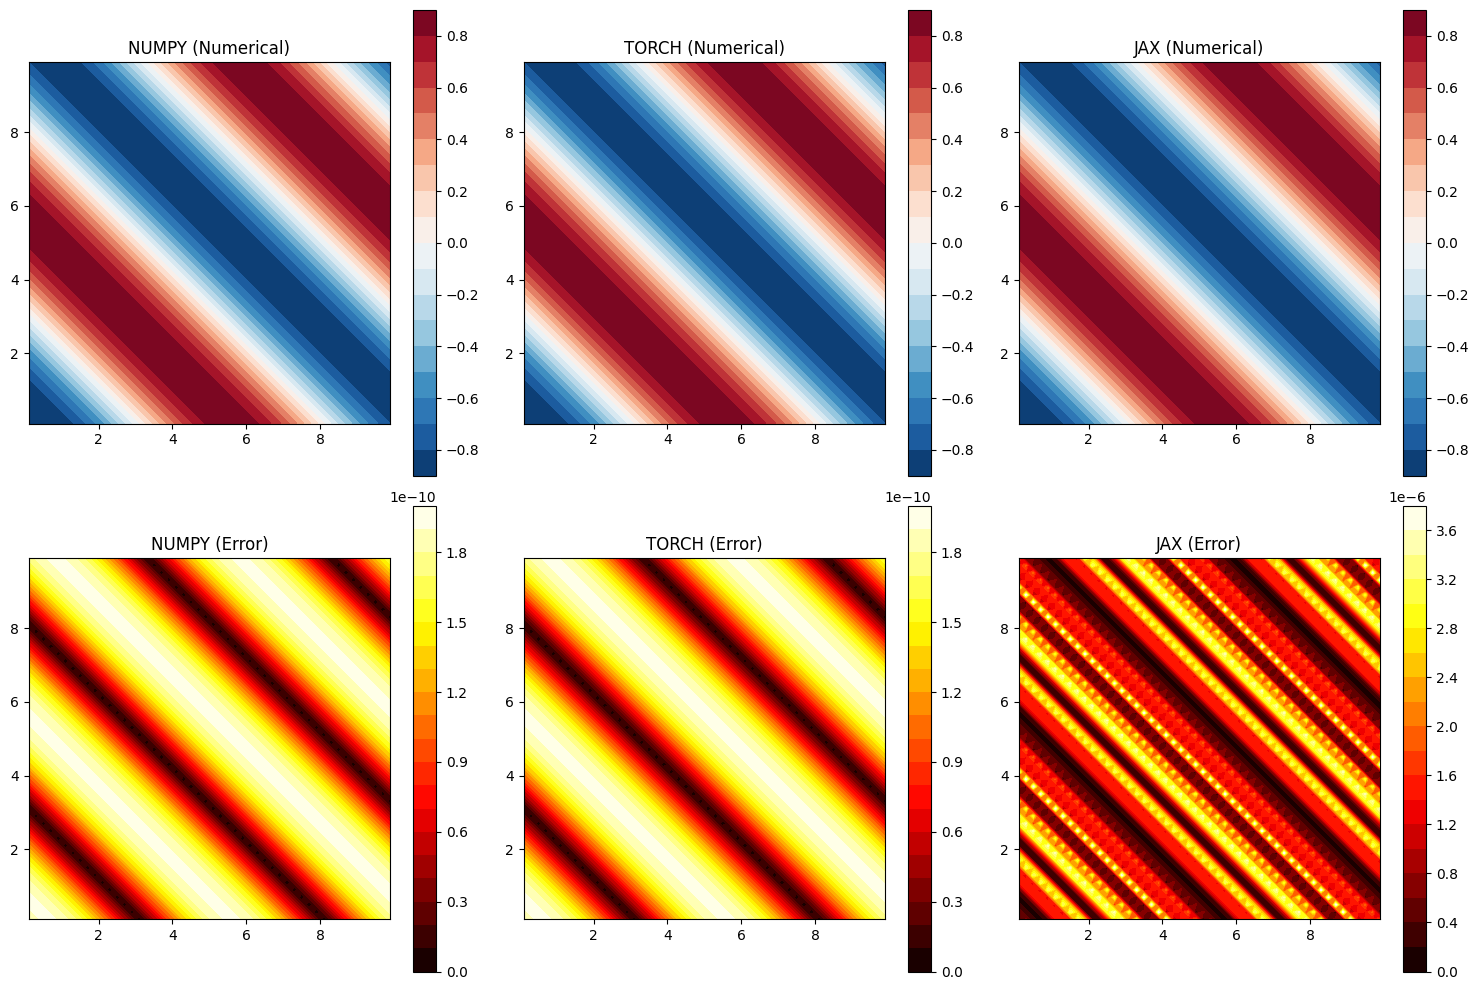


📊 SUMMARY TABLE (5-point method on 2D wave)
------------------------------------------------------------
Backend      Error           Time (s)    
------------------------------------------------------------
numpy        1.922980e-10   0.000671
torch        1.922980e-10   0.001921
jax          5.348845e-06   0.081845


In [8]:
"""
TEST: TimeGradient on 2D Wave Field
"""

from QSER.Operators import TimeGradient
from QSER.Mesh import Structured2D
import numpy as np
import matplotlib.pyplot as plt
import time

# ============================================================
# 1. Create mesh and wave field
# ============================================================

nx, ny = 50, 50
Lx, Ly = 10.0, 10.0
mesh = Structured2D(nx=nx, ny=ny, Lx=Lx, Ly=Ly, backend='numpy')

X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]

# Wave parameters
kx = 2 * np.pi / Lx
ky = 2 * np.pi / Ly
omega = np.sqrt(kx**2 + ky**2)

# Time array
nt = 100
t = np.linspace(0, 1.0, nt)
dt = t[1] - t[0]

# Create 3D field: (time, x, y)
u = np.zeros((nt, nx, ny))
for i, ti in enumerate(t):
    u[i, :, :] = np.sin(kx * X + ky * Y - omega * ti)

# Analytical time derivative: (time, x, y)
u_dot_analytical = np.zeros((nt, nx, ny))
for i, ti in enumerate(t):
    u_dot_analytical[i, :, :] = -omega * np.cos(kx * X + ky * Y - omega * ti)

print("=" * 70)
print("2D WAVE FIELD TEST")
print("=" * 70)
print(f"Grid: {nx} x {ny}")
print(f"Time steps: {nt}")
print(f"dt: {dt:.4f}")
print(f"kx: {kx:.4f}, ky: {ky:.4f}, omega: {omega:.4f}")

# ============================================================
# 2. Test TimeGradient on the 3D field
# ============================================================

backends = ['numpy', 'torch', 'jax']
methods = ['central', '5point', 'forward', 'backward', 'least_squares']

print("\n" + "-" * 70)
print(f"{'Backend':<10} {'Method':<14} {'Error':<15} {'Time (s)':<12} {'Status'}")
print("-" * 70)

results = {}

for backend in backends:
    try:
        time_grad = TimeGradient(backend=backend)
        results[backend] = {}
        
        for method in methods:
            start = time.time()
            
            # Convert to backend
            if backend == 'torch':
                import torch
                u_b = torch.tensor(u, dtype=torch.float64)
                u_dot = time_grad.compute(u_b, dt=dt, method=method, axis=0)
                u_dot = u_dot.numpy()
            elif backend == 'jax':
                import jax.numpy as jnp
                u_b = jnp.array(u)
                u_dot = time_grad.compute(u_b, dt=dt, method=method, axis=0)
                u_dot = np.array(u_dot)
            else:
                u_dot = time_grad.compute(u, dt=dt, method=method, axis=0)
            
            elapsed = time.time() - start
            
            # Error (exclude boundaries in time and space)
            error = np.max(np.abs(u_dot[4:-4, 2:-2, 2:-2] - u_dot_analytical[4:-4, 2:-2, 2:-2]))
            status = "✅" if error < 1e-3 else "❌"
            
            print(f"{backend:<10} {method:<14} {error:.6e}   {elapsed:.6f}    {status}")
            
            results[backend][method] = {'error': error, 'time': elapsed}
            
    except Exception as e:
        print(f"{backend:<10} {'ERROR':<14} {str(e)[:40]:<40}")

print("\n" + "=" * 70)

# ============================================================
# 3. Visualize results
# ============================================================

# Pick a time slice
time_idx = nt // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, backend in enumerate(backends):
    if backend not in results:
        continue
    
    # Compute using 5-point method
    try:
        time_grad = TimeGradient(backend=backend)
        
        if backend == 'torch':
            import torch
            u_b = torch.tensor(u, dtype=torch.float64)
            u_dot = time_grad.compute(u_b, dt=dt, method='5point', axis=0)
            u_dot = u_dot.numpy()
        elif backend == 'jax':
            import jax.numpy as jnp
            u_b = jnp.array(u)
            u_dot = time_grad.compute(u_b, dt=dt, method='5point', axis=0)
            u_dot = np.array(u_dot)
        else:
            u_dot = time_grad.compute(u, dt=dt, method='5point', axis=0)
        
        # Plot numerical
        ax = axes[0, idx]
        im = ax.contourf(X, Y, u_dot[time_idx, :, :], levels=20, cmap='RdBu_r')
        ax.set_title(f'{backend.upper()} (Numerical)')
        ax.set_aspect('equal')
        plt.colorbar(im, ax=ax)
        
        # Plot error
        ax = axes[1, idx]
        error_field = np.abs(u_dot[time_idx, :, :] - u_dot_analytical[time_idx, :, :])
        im = ax.contourf(X, Y, error_field, levels=20, cmap='hot')
        ax.set_title(f'{backend.upper()} (Error)')
        ax.set_aspect('equal')
        plt.colorbar(im, ax=ax)
        
    except Exception as e:
        axes[0, idx].text(0.5, 0.5, f'ERROR: {str(e)[:30]}', ha='center', va='center')
        axes[0, idx].set_title(f'{backend.upper()} (FAILED)')

plt.tight_layout()
plt.show()

# ============================================================
# 4. Summary
# ============================================================

print("\n📊 SUMMARY TABLE (5-point method on 2D wave)")
print("-" * 60)
print(f"{'Backend':<12} {'Error':<15} {'Time (s)':<12}")
print("-" * 60)

for backend in backends:
    if backend in results and '5point' in results[backend]:
        error = results[backend]['5point']['error']
        elapsed = results[backend]['5point']['time']
        print(f"{backend:<12} {error:.6e}   {elapsed:.6f}")

### testing time gradient, jax and torch backend

TIME GRADIENT — BACKEND COMPARISON

Backend    Method         Error           Time (s)     Status
----------------------------------------------------------------------
numpy      central        1.669995e-05   0.000230    ✅
numpy      5point         3.346660e-10   0.000388    ✅
numpy      forward        1.669995e-05   0.000236    ✅
numpy      backward       1.669995e-05   0.000234    ✅
numpy      least_squares  1.669995e-05   0.000217    ✅
torch      central        1.669995e-05   0.004676    ✅
torch      5point         3.346660e-10   0.010364    ✅
torch      forward        1.669995e-05   0.003961    ✅
torch      backward       1.669995e-05   0.003916    ✅
torch      least_squares  1.669995e-05   0.003931    ✅
jax        central        1.712074e-05   0.245772    ✅
jax        5point         5.509118e-06   0.262536    ✅
jax        forward        1.712074e-05   0.191677    ✅
jax        backward       1.712074e-05   0.193230    ✅
jax        least_squares  1.712074e-05   0.190350    ✅



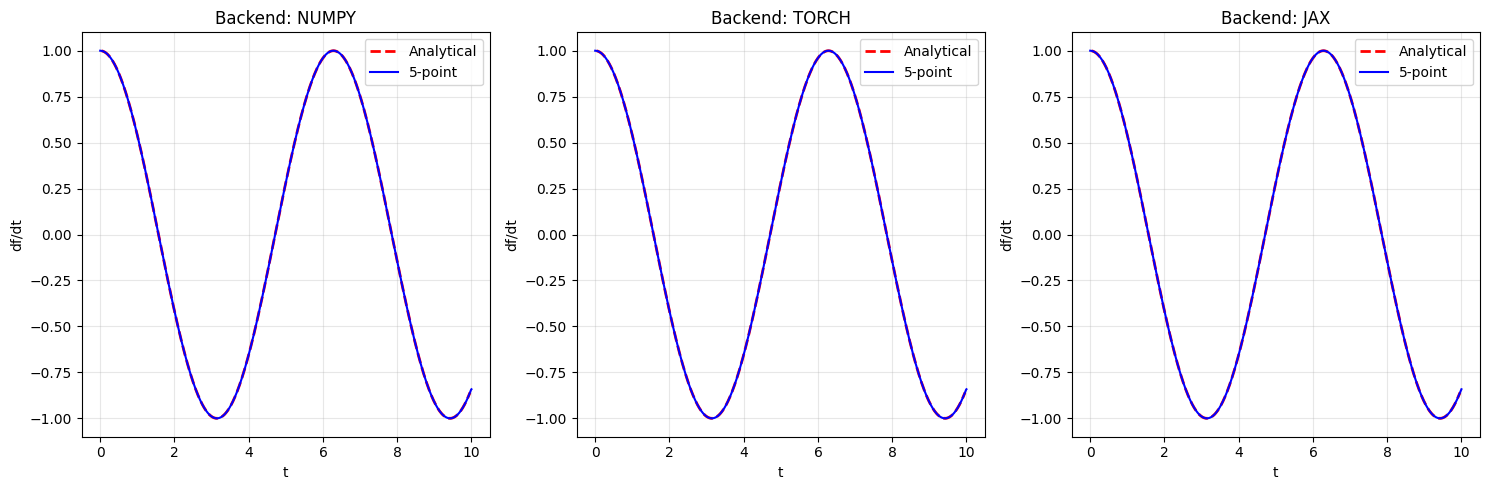


📊 SUMMARY TABLE (5-point method)
--------------------------------------------------
Backend      Error           Time (s)    
--------------------------------------------------
numpy        3.346660e-10   0.000388
torch        3.346660e-10   0.010364
jax          5.509118e-06   0.262536


In [9]:
from QSER.Operators import TimeGradient
import numpy as np
import matplotlib.pyplot as plt
import time

# Create a time series: f(t) = sin(t)
t = np.linspace(0, 10, 1000)  # More points for better comparison
dt = t[1] - t[0]
f = np.sin(t)

# Analytical derivative: cos(t)
f_analytical = np.cos(t)

# Backends to test
backends = ['numpy', 'torch', 'jax']
methods = ['central', '5point', 'forward', 'backward', 'least_squares']

print("=" * 80)
print("TIME GRADIENT — BACKEND COMPARISON")
print("=" * 80)
print(f"\n{'Backend':<10} {'Method':<14} {'Error':<15} {'Time (s)':<12} {'Status'}")
print("-" * 70)

results = {}

for backend in backends:
    try:
        time_grad = TimeGradient(backend=backend)
        results[backend] = {}
        
        for method in methods:
            start = time.time()
            
            # Convert field to backend if needed
            if backend == 'torch':
                import torch
                f_b = torch.tensor(f, dtype=torch.float64)
                f_dot = time_grad.compute(f_b, dt=dt, method=method)
                f_dot = f_dot.numpy()
            elif backend == 'jax':
                import jax.numpy as jnp
                f_b = jnp.array(f)
                f_dot = time_grad.compute(f_b, dt=dt, method=method)
                f_dot = np.array(f_dot)
            else:
                f_dot = time_grad.compute(f, dt=dt, method=method)
            
            elapsed = time.time() - start
            
            # Error (exclude boundaries)
            error = np.max(np.abs(f_dot[4:-4] - f_analytical[4:-4]))
            status = "✅" if error < 1e-4 else "❌"
            
            print(f"{backend:<10} {method:<14} {error:.6e}   {elapsed:.6f}    {status}")
            
            results[backend][method] = {'error': error, 'time': elapsed}
            
    except Exception as e:
        print(f"{backend:<10} {'ERROR':<14} {str(e)[:40]:<40}")

print("\n" + "=" * 80)

# ============================================================
# Plot comparison
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, backend in enumerate(backends):
    if backend not in results:
        continue
    
    ax = axes[idx]
    
    # Get 5-point method result
    try:
        time_grad = TimeGradient(backend=backend)
        
        if backend == 'torch':
            import torch
            f_b = torch.tensor(f, dtype=torch.float64)
            f_dot = time_grad.compute(f_b, dt=dt, method='5point')
            f_dot = f_dot.numpy()
        elif backend == 'jax':
            import jax.numpy as jnp
            f_b = jnp.array(f)
            f_dot = time_grad.compute(f_b, dt=dt, method='5point')
            f_dot = np.array(f_dot)
        else:
            f_dot = time_grad.compute(f, dt=dt, method='5point')
        
        ax.plot(t[4:-4], f_analytical[4:-4], 'r--', linewidth=2, label='Analytical')
        ax.plot(t, f_dot, 'b-', linewidth=1.5, label='5-point')
        ax.set_xlabel('t')
        ax.set_ylabel('df/dt')
        ax.set_title(f'Backend: {backend.upper()}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    except Exception as e:
        ax.text(0.5, 0.5, f'ERROR: {str(e)[:30]}', ha='center', va='center')
        ax.set_title(f'Backend: {backend.upper()} (FAILED)')

plt.tight_layout()
plt.show()

# ============================================================
# Summary table
# ============================================================

print("\n📊 SUMMARY TABLE (5-point method)")
print("-" * 50)
print(f"{'Backend':<12} {'Error':<15} {'Time (s)':<12}")
print("-" * 50)

for backend in backends:
    if backend in results and '5point' in results[backend]:
        error = results[backend]['5point']['error']
        elapsed = results[backend]['5point']['time']
        print(f"{backend:<12} {error:.6e}   {elapsed:.6f}")

## Testing time gradient numpy backend

TIME GRADIENT TEST — ALL METHODS

Method         Error           Status
--------------------------------------------------
central        1.699550e-03   ❌
5point         3.465672e-06   ✅
forward        1.699550e-03   ❌
backward       1.699550e-03   ❌
least_squares  1.699550e-03   ❌


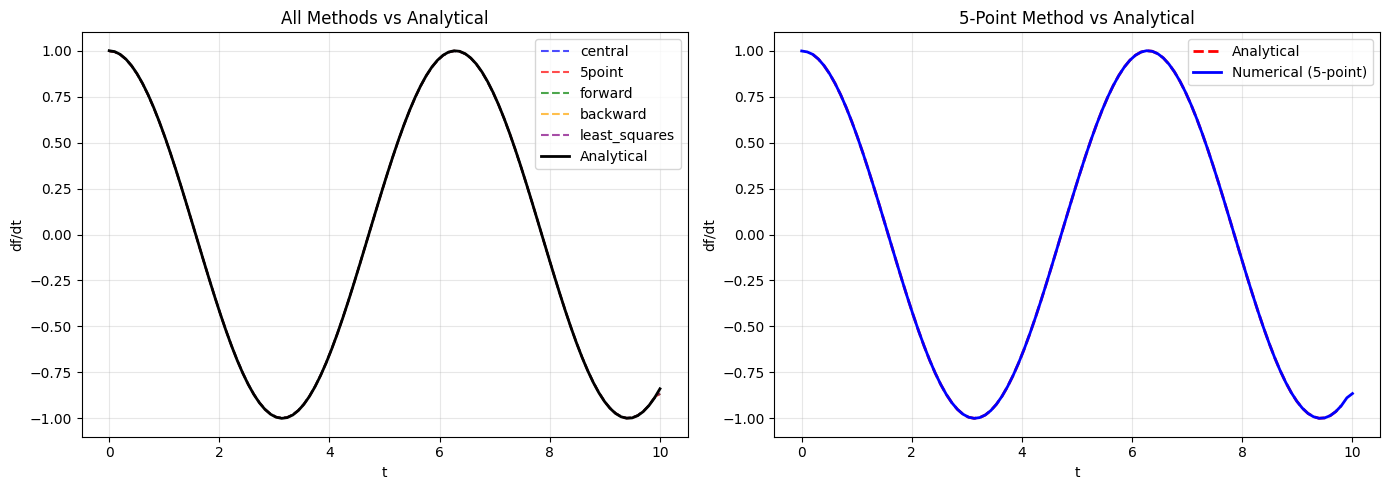


📊 LEAST SQUARES VERIFICATION
----------------------------------------
least_squares error: 1.699550e-03
Same as central: ✅


In [10]:
from QSER.Operators import TimeGradient
import numpy as np
import matplotlib.pyplot as plt

# Create a time series: f(t) = sin(t)
t = np.linspace(0, 10, 100)
dt = t[1] - t[0]
f = np.sin(t)

# Analytical derivative: cos(t)
f_analytical = np.cos(t)

# Compute time gradient
time_grad = TimeGradient()

# Test all methods
methods = ['central', '5point', 'forward', 'backward', 'least_squares']

print("=" * 70)
print("TIME GRADIENT TEST — ALL METHODS")
print("=" * 70)
print(f"\n{'Method':<14} {'Error':<15} {'Status'}")
print("-" * 50)

for method in methods:
    f_dot = time_grad.compute(f, dt=dt, method=method)
    # Exclude boundaries for error calculation
    error = np.max(np.abs(f_dot[2:-2] - f_analytical[2:-2]))
    status = "✅" if error < 1e-3 else "❌"
    print(f"{method:<14} {error:.6e}   {status}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: All methods
ax = axes[0]
colors = {'central': 'blue', '5point': 'red', 'forward': 'green', 'backward': 'orange', 'least_squares': 'purple'}
for method in methods:
    f_dot = time_grad.compute(f, dt=dt, method=method)
    ax.plot(t, f_dot, '--', label=method, color=colors.get(method, 'gray'), alpha=0.7)
ax.plot(t, f_analytical, 'k-', linewidth=2, label='Analytical')
ax.set_xlabel('t')
ax.set_ylabel('df/dt')
ax.set_title('All Methods vs Analytical')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Best method (5point)
ax = axes[1]
f_dot_5p = time_grad.compute(f, dt=dt, method='5point')
ax.plot(t[2:-2], f_analytical[2:-2], 'r--', linewidth=2, label='Analytical')
ax.plot(t, f_dot_5p, 'b-', linewidth=2, label='Numerical (5-point)')
ax.set_xlabel('t')
ax.set_ylabel('df/dt')
ax.set_title('5-Point Method vs Analytical')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check least_squares error
print("\n📊 LEAST SQUARES VERIFICATION")
print("-" * 40)
f_dot_ls = time_grad.compute(f, dt=dt, method='least_squares')
error_ls = np.max(np.abs(f_dot_ls[2:-2] - f_analytical[2:-2]))
print(f"least_squares error: {error_ls:.6e}")
print(f"Same as central: {'✅' if error_ls == np.max(np.abs(time_grad.compute(f, dt=dt, method='central')[2:-2] - f_analytical[2:-2])) else '⚠️'}")

### testing time again

TIME GRADIENT TEST

Method       Error           Status
----------------------------------------
central      1.699550e-03   ❌
5point       3.465672e-06   ✅
forward      1.699550e-03   ❌
backward     1.699550e-03   ❌


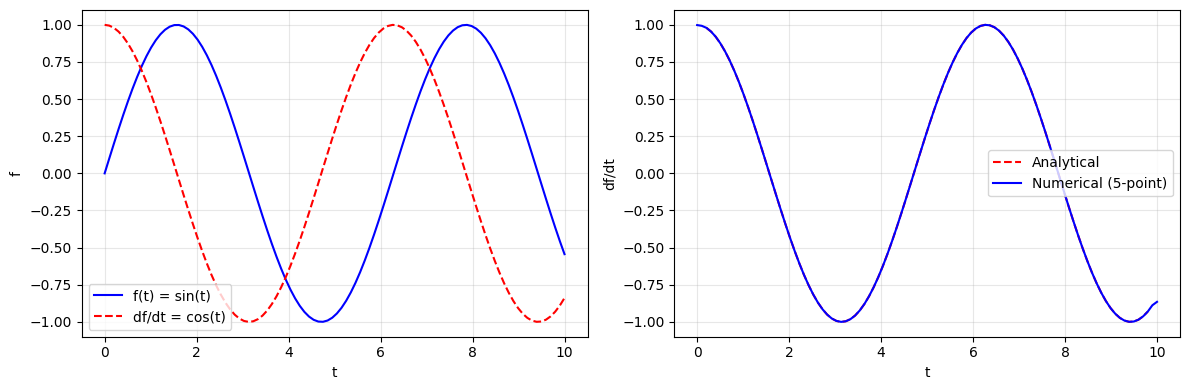

In [11]:
from QSER.Operators import TimeGradient
import numpy as np
import matplotlib.pyplot as plt

# Create a time series: f(t) = sin(t)
t = np.linspace(0, 10, 100)
dt = t[1] - t[0]
f = np.sin(t)

# Analytical derivative: cos(t)
f_analytical = np.cos(t)

# Compute time gradient
time_grad = TimeGradient(backend='numpy')

# Test different methods
methods = ['central', '5point', 'forward', 'backward']

print("=" * 60)
print("TIME GRADIENT TEST")
print("=" * 60)
print(f"\n{'Method':<12} {'Error':<15} {'Status'}")
print("-" * 40)

for method in methods:
    f_dot = time_grad.compute(f, dt=dt, method=method)
    # Exclude boundaries for error calculation
    error = np.max(np.abs(f_dot[2:-2] - f_analytical[2:-2]))
    status = "✅" if error < 1e-3 else "❌"
    print(f"{method:<12} {error:.6e}   {status}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: f(t) and analytical derivative
ax = axes[0]
ax.plot(t, f, 'b-', label='f(t) = sin(t)')
ax.plot(t, f_analytical, 'r--', label="df/dt = cos(t)")
ax.set_xlabel('t')
ax.set_ylabel('f')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Numerical vs Analytical
ax = axes[1]
f_dot_5p = time_grad.compute(f, dt=dt, method='5point')
ax.plot(t[2:-2], f_analytical[2:-2], 'r--', label='Analytical')
ax.plot(t, f_dot_5p, 'b-', label='Numerical (5-point)')
ax.set_xlabel('t')
ax.set_ylabel('df/dt')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## verify enegry tracker

In [12]:
"""
TEST: EnergyTracker — Mesh-based (Original User Experience)
"""

from QSER.Mesh import Structured1D
from QSER.Energy import EnergyTracker
import numpy as np

print("=" * 70)
print("TEST: ENERGYTRACKER — MESH-BASED (ORIGINAL)")
print("=" * 70)

# Create mesh
mesh = Structured1D(nx=100, L=10.0, backend='numpy')
x = mesh.get_cell_centers()

# Create fields
S = np.sin(x)
E = np.cos(x)
R = S - E

# EnergyTracker with mesh (original way)
tracker = EnergyTracker(mesh=mesh)

eps_S = tracker.epsilon_S(S)
eps_E = tracker.epsilon_E(E)
eps_R = tracker.epsilon_R(R)

print(f"ε_S: {eps_S:.6f}")
print(f"ε_E: {eps_E:.6f}")
print(f"ε_R: {eps_R:.6f}")
print("✅ Mesh-based EnergyTracker works")

TEST: ENERGYTRACKER — MESH-BASED (ORIGINAL)
ε_S: 23.793438
ε_E: 25.706562
ε_R: 48.259605
✅ Mesh-based EnergyTracker works


## testing with random values

In [13]:
"""
TEST: EnergyTracker — Stand-alone 2D with dx, dy
"""

from QSER.Energy import EnergyTracker
import numpy as np

print("=" * 70)
print("TEST: ENERGYTRACKER — STAND-ALONE 2D")
print("=" * 70)

tracker = EnergyTracker()

# 2D field (time, space)
S = np.random.randn(10, 100)
E = np.random.randn(10, 100)
R = S - E

# Pass dx and dy for 2D integration
dx = 1.0
dy = 1.0
volume = 0.1

eps_S = tracker.epsilon_S(S, volume=volume, dx=dx, dy=dy)
eps_E = tracker.epsilon_E(E, volume=volume, dx=dx, dy=dy)
eps_R = tracker.epsilon_R(R, volume=volume, dx=dx, dy=dy)

print(f"ε_S: {eps_S:.6f}")
print(f"ε_E: {eps_E:.6f}")
print(f"ε_R: {eps_R:.6f}")
print("✅ Energy module ready")

print("\n" + "=" * 70)
print("✅ TEST COMPLETE")
print("=" * 70)

TEST: ENERGYTRACKER — STAND-ALONE 2D
ε_S: 43.792367
ε_E: 46.101608
ε_R: 89.307146
✅ Energy module ready

✅ TEST COMPLETE


## User experience Geometry

# Geometry sphere

Vertices: 642
Faces: 1280
Bounds: (np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))
Volume: 4.1527
Interior: (500, 3)
Boundary: (200, 3)
✅ Figure saved: geometry_sphere.png


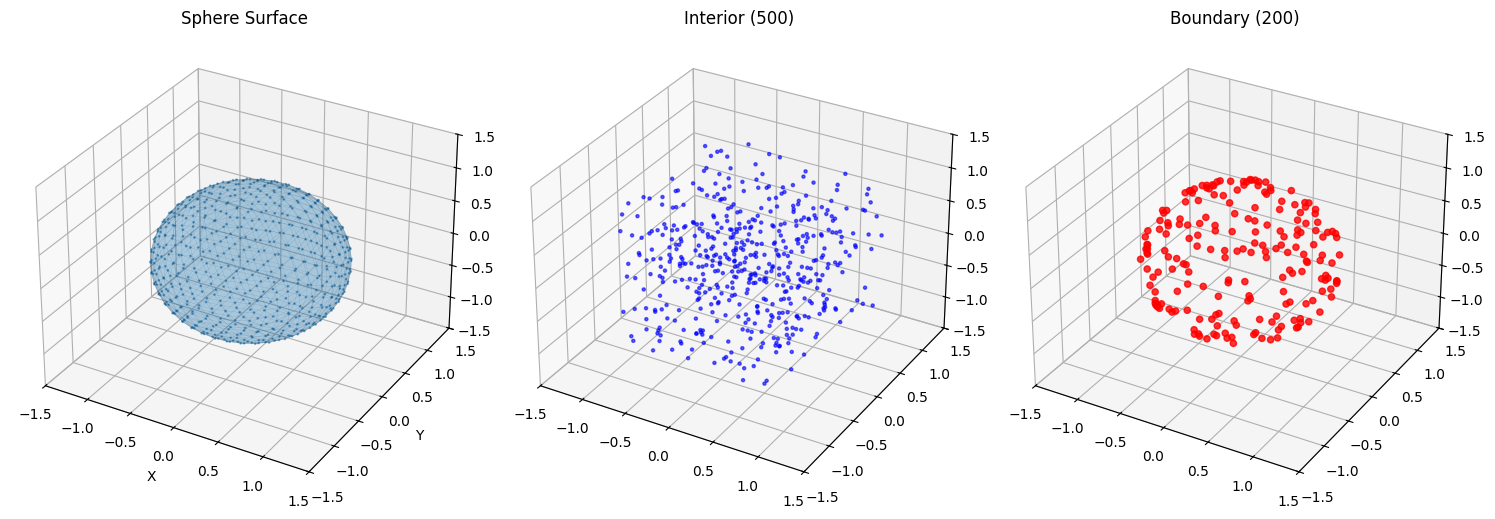

In [14]:
from QSER.Geometry import Geometry
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os


# Create sphere
geo = Geometry.sphere(radius=1.0, center=(0, 0, 0))

print(f"Vertices: {geo.n_vertices}")
print(f"Faces: {geo.n_faces}")
print(f"Bounds: {geo.bounding_box()}")
print(f"Volume: {geo.volume():.4f}")

# Sample points
interior = geo.sample_points(n_points=500, method='random', seed=42)
boundary = geo.sample_boundary(n_points=200, method='uniform', seed=42)

print(f"Interior: {interior.shape}")
print(f"Boundary: {boundary.shape}")

# Plot
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
geo.plot(ax=ax1, show_vertices=True, show_faces=True)
ax1.set_title('Sphere Surface')
ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-1.5, 1.5)
ax1.set_zlim(-1.5, 1.5)

ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(interior[:, 0], interior[:, 1], interior[:, 2], 
            c='blue', s=5, alpha=0.6)
ax2.set_title(f'Interior ({len(interior)})')
ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1.5, 1.5)
ax2.set_zlim(-1.5, 1.5)

ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(boundary[:, 0], boundary[:, 1], boundary[:, 2], 
            c='red', s=20, alpha=0.8)
ax3.set_title(f'Boundary ({len(boundary)})')
ax3.set_xlim(-1.5, 1.5)
ax3.set_ylim(-1.5, 1.5)
ax3.set_zlim(-1.5, 1.5)

plt.tight_layout()


plt.show()

## Cad file import to geometry

✅ Valid STEP file created: /tmp/test_cube_valid.step

📐 Geometry Info:
  Vertices: 8
  Faces: 12
  Bounds: (np.float32(-0.5), np.float32(0.5), np.float32(-0.5), np.float32(0.5), np.float32(-0.5), np.float32(0.5))
  Volume: 1.0000

📊 Sampling:
  Interior: (300, 3)
  Boundary: (100, 3)
✅ Figure saved: geometry_cad.png


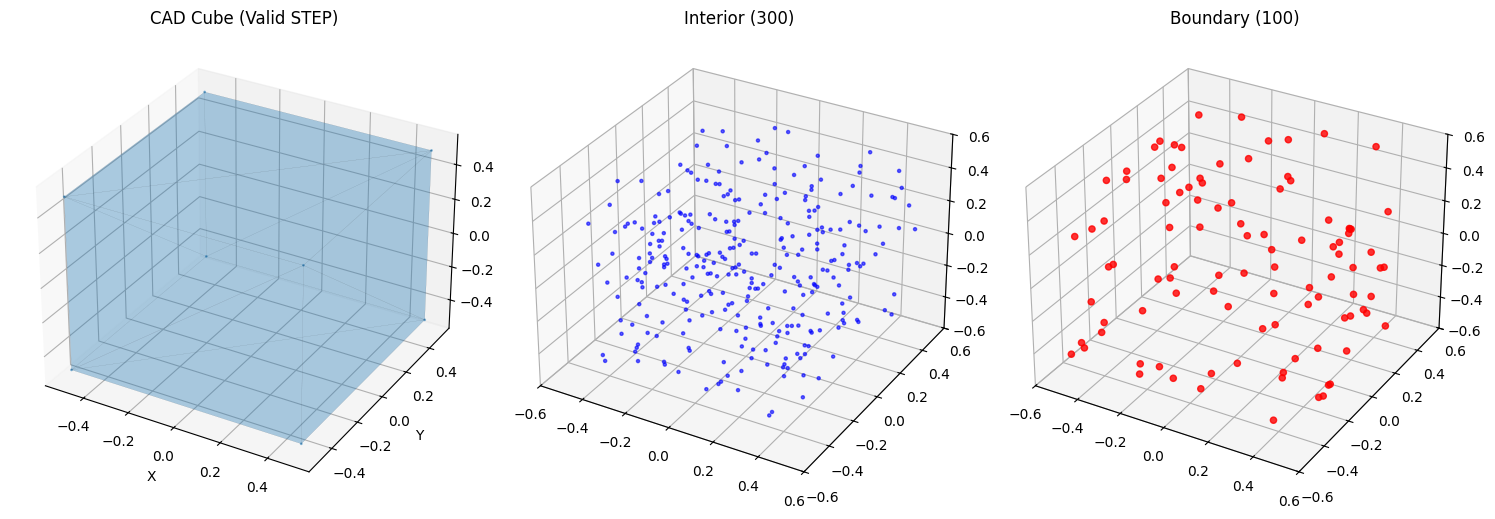

In [15]:
# Create a valid STEP file using cadquery
import cadquery as cq
from QSER.Geometry import Geometry
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os

# ============================================================
# CREATE A VALID STEP FILE
# ============================================================

# Create a cube using cadquery
result = cq.Workplane("XY").box(1.0, 1.0, 1.0)

# Export to STEP
step_path = "/tmp/test_cube_valid.step"
cq.exporters.export(result, step_path, "STEP")

print(f"✅ Valid STEP file created: {step_path}")

# ============================================================
# NOW IMPORT IT
# ============================================================


# Import from valid STEP file
geo = Geometry.from_cad(step_path)

print(f"\n📐 Geometry Info:")
print(f"  Vertices: {geo.n_vertices}")
print(f"  Faces: {geo.n_faces}")
print(f"  Bounds: {geo.bounding_box()}")
print(f"  Volume: {geo.volume():.4f}")

# Sample points
interior = geo.sample_points(n_points=300, method='random', seed=42)
boundary = geo.sample_boundary(n_points=100, method='uniform', seed=42)

print(f"\n📊 Sampling:")
print(f"  Interior: {interior.shape}")
print(f"  Boundary: {boundary.shape}")

# Plot
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
geo.plot(ax=ax1, show_vertices=True, show_faces=True)
ax1.set_title('CAD Cube (Valid STEP)')

ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(interior[:, 0], interior[:, 1], interior[:, 2], c='blue', s=5, alpha=0.6)
ax2.set_title(f'Interior ({len(interior)})')
ax2.set_xlim(-0.6, 0.6); ax2.set_ylim(-0.6, 0.6); ax2.set_zlim(-0.6, 0.6)

ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(boundary[:, 0], boundary[:, 1], boundary[:, 2], c='red', s=20, alpha=0.8)
ax3.set_title(f'Boundary ({len(boundary)})')
ax3.set_xlim(-0.6, 0.6); ax3.set_ylim(-0.6, 0.6); ax3.set_zlim(-0.6, 0.6)

plt.tight_layout()

# Save
fig.savefig(os.path.join(FIGURES_DIR, "geometry_cad.png"), dpi=300, bbox_inches='tight')
print("✅ Figure saved: geometry_cad.png")
plt.show()

In [16]:
#!pip install cadquery

# STL file import to geometry test

✅ STL file created: /tmp/test.stl
Vertices: 4
Faces: 4
Bounds: (np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(1.0))
Volume: 0.1667
Interior: (100, 3)
Boundary: (50, 3)
✅ Figure saved: geometry_stl.png


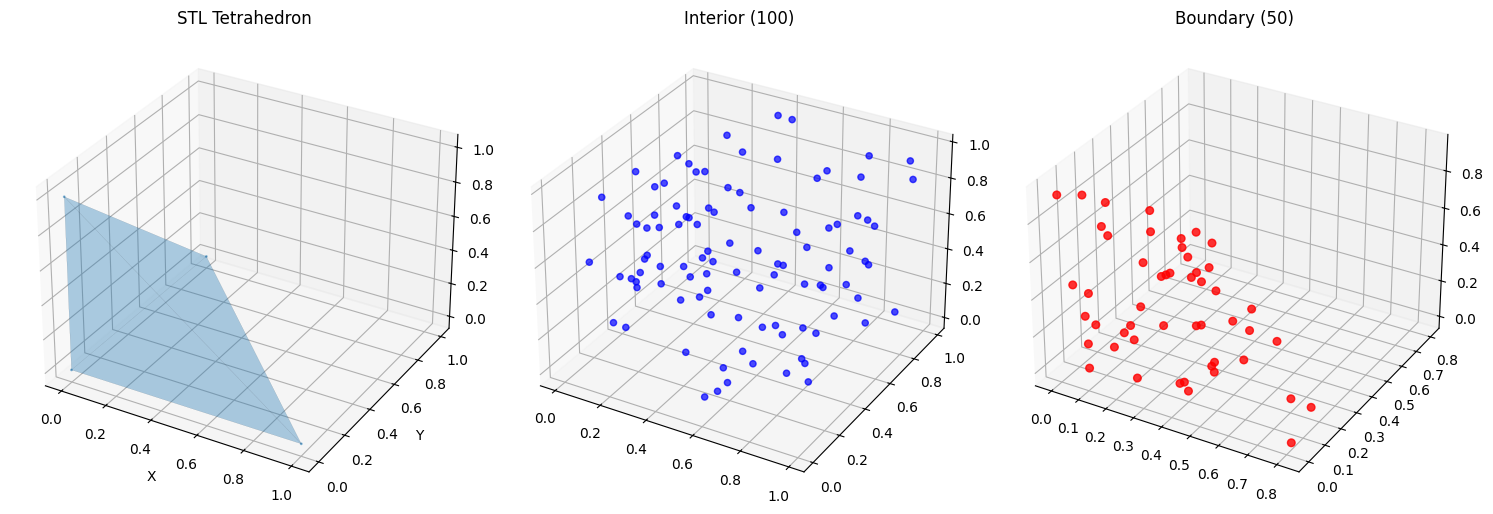

In [17]:
from QSER.Geometry import Geometry
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os

# Figures directory
FIGURES_DIR = "/home/ahmad/Yandex.Disk/Research/Q theory/QSER solver 2026/QSER user guide book/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Create a simple STL file (tetrahedron)
stl_content = """solid test
  facet normal 0.0 0.0 -1.0
    outer loop
      vertex 0.0 0.0 0.0
      vertex 1.0 0.0 0.0
      vertex 0.0 1.0 0.0
    endloop
  endfacet
  facet normal 0.0 0.0 1.0
    outer loop
      vertex 0.0 0.0 1.0
      vertex 1.0 0.0 0.0
      vertex 0.0 1.0 0.0
    endloop
  endfacet
  facet normal -1.0 0.0 0.0
    outer loop
      vertex 0.0 0.0 0.0
      vertex 0.0 0.0 1.0
      vertex 0.0 1.0 0.0
    endloop
  endfacet
  facet normal 0.0 -1.0 0.0
    outer loop
      vertex 0.0 0.0 0.0
      vertex 0.0 0.0 1.0
      vertex 1.0 0.0 0.0
    endloop
  endfacet
endsolid test
"""

stl_path = "/tmp/test.stl"
with open(stl_path, 'w') as f:
    f.write(stl_content)
print(f"✅ STL file created: {stl_path}")

# Import from STL
geo = Geometry.from_stl(stl_path)

print(f"Vertices: {geo.n_vertices}")
print(f"Faces: {geo.n_faces}")
print(f"Bounds: {geo.bounding_box()}")
print(f"Volume: {geo.volume():.4f}")

# Sample interior
interior = geo.sample_points(n_points=100, method='random', seed=42)
print(f"Interior: {interior.shape}")

# Sample boundary
boundary = geo.sample_boundary(n_points=50, method='uniform', seed=42)
print(f"Boundary: {boundary.shape}")

# Plot
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
geo.plot(ax=ax1, show_vertices=True, show_faces=True)
ax1.set_title('STL Tetrahedron')

ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(interior[:, 0], interior[:, 1], interior[:, 2], c='blue', s=20, alpha=0.7)
ax2.set_title(f'Interior ({len(interior)})')

ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(boundary[:, 0], boundary[:, 1], boundary[:, 2], c='red', s=30, alpha=0.8)
ax3.set_title(f'Boundary ({len(boundary)})')

plt.tight_layout()

# Save
fig.savefig(os.path.join(FIGURES_DIR, "geometry_stl.png"), dpi=300, bbox_inches='tight')
print("✅ Figure saved: geometry_stl.png")
plt.show()

In [18]:
#!pip install numpy-stl

## Excel import geometry

✅ Excel file created: /tmp/test_points.xlsx
Points: 15
Bounds: (np.float64(-0.5), np.float64(1.0), np.float64(-0.5), np.float64(1.0), np.float64(-0.5), np.float64(1.0))
Sampled: (30, 3)
✅ Figure saved: geometry_excel.png


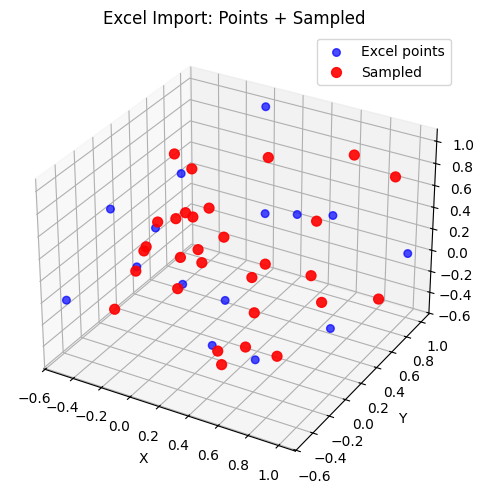

In [19]:
from QSER.Geometry import Geometry
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os
import pandas as pd



# Create a test Excel file
excel_path = "/tmp/test_points.xlsx"
df = pd.DataFrame({
    'x': [0.0, 1.0, 0.0, 0.0, 0.5, 1.0, 0.0, 1.0, -0.5, 0.0, 0.5, -0.5, 0.5, -0.5, 0.0],
    'y': [0.0, 0.0, 1.0, 0.0, 0.5, 1.0, 1.0, 0.0, -0.5, -0.5, 0.0, 0.0, -0.5, 0.5, 0.5],
    'z': [0.0, 0.0, 0.0, 1.0, 0.5, 0.0, 1.0, 1.0, 0.0, 0.5, -0.5, 0.5, 0.0, 0.0, -0.5]
})
df.to_excel(excel_path, index=False)
print(f"✅ Excel file created: {excel_path}")

# Import from Excel
geo = Geometry.from_excel(excel_path)

print(f"Points: {geo.n_vertices}")
print(f"Bounds: {geo.bounding_box()}")

# Sample
sampled = geo.sample_points(n_points=30, method='random', seed=42)
print(f"Sampled: {sampled.shape}")

# Plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(geo.vertices[:, 0], geo.vertices[:, 1], geo.vertices[:, 2], 
           c='blue', s=30, alpha=0.7, label='Excel points')
ax.scatter(sampled[:, 0], sampled[:, 1], sampled[:, 2], 
           c='red', s=50, alpha=0.9, label='Sampled')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Excel Import: Points + Sampled')
ax.legend()

plt.tight_layout()
plt.show()

## Testing CSV import

Points: 15
Bounds: (np.float64(-0.5), np.float64(1.0), np.float64(-0.5), np.float64(1.0), np.float64(-0.5), np.float64(1.0))
Sampled: (30, 3)
✅ Figure saved: geometry_csv.png


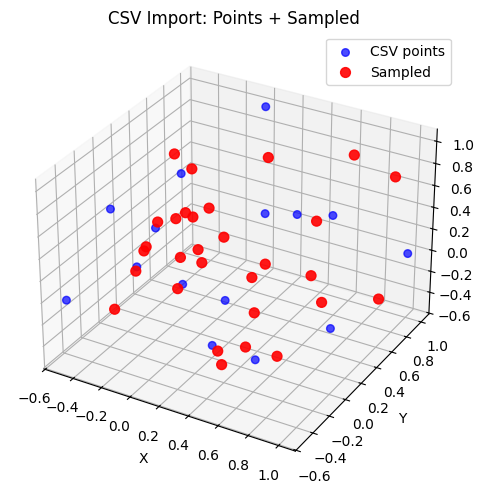

In [20]:
from QSER.Geometry import Geometry
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os
import pandas as pd
from io import StringIO

# Figures directory
FIGURES_DIR = "path"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Create a test CSV file (in memory)
csv_data = """x,y,z
0.0,0.0,0.0
1.0,0.0,0.0
0.0,1.0,0.0
0.0,0.0,1.0
0.5,0.5,0.5
1.0,1.0,0.0
0.0,1.0,1.0
1.0,0.0,1.0
-0.5,-0.5,0.0
0.0,-0.5,0.5
0.5,0.0,-0.5
-0.5,0.0,0.5
0.5,-0.5,0.0
-0.5,0.5,0.0
0.0,0.5,-0.5
"""

# Save to file
csv_path = "/tmp/test_points.csv"
with open(csv_path, 'w') as f:
    f.write(csv_data)

# Import from CSV
geo = Geometry.from_csv(csv_path)

print(f"Points: {geo.n_vertices}")
print(f"Bounds: {geo.bounding_box()}")

# Sample
sampled = geo.sample_points(n_points=30, method='random', seed=42)
print(f"Sampled: {sampled.shape}")

# Plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(geo.vertices[:, 0], geo.vertices[:, 1], geo.vertices[:, 2], 
           c='blue', s=30, alpha=0.7, label='CSV points')
ax.scatter(sampled[:, 0], sampled[:, 1], sampled[:, 2], 
           c='red', s=50, alpha=0.9, label='Sampled')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('CSV Import: Points + Sampled')
ax.legend()

plt.tight_layout()



plt.show()

## Point cloud geometry

Points: 200
Bounds: (np.float64(-1.9779115315055904), np.float64(1.9988706931445224), np.float64(-1.9797536646151253), np.float64(1.9865473482956215), np.float64(-1.9721914778752372), np.float64(1.9491045172597778))
Sampled: (100, 3)
✅ Figure saved: geometry_from_points.png


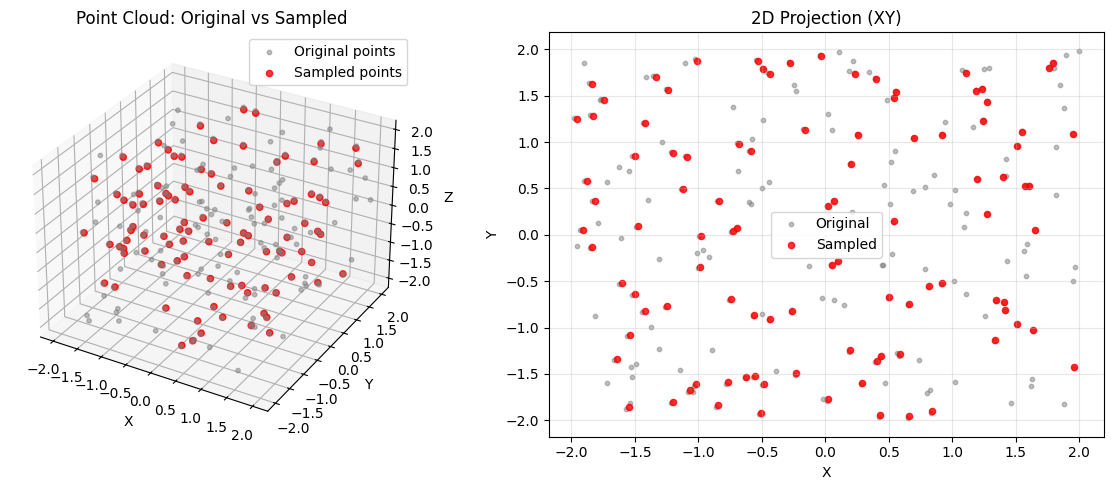

In [21]:
from QSER.Geometry import Geometry
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os


# Generate random points in a cube
np.random.seed(42)
points = np.random.rand(200, 3) * 4 - 2  # Range: -2 to 2

# Create geometry from points
geo = Geometry.from_points(points)

print(f"Points: {geo.n_vertices}")
print(f"Bounds: {geo.bounding_box()}")

# Sample from the point cloud
sampled = geo.sample_points(n_points=100, method='random', seed=42)
print(f"Sampled: {sampled.shape}")

# Plot
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(points[:, 0], points[:, 1], points[:, 2], 
            c='gray', s=10, alpha=0.5, label='Original points')
ax1.scatter(sampled[:, 0], sampled[:, 1], sampled[:, 2], 
            c='red', s=20, alpha=0.8, label='Sampled points')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_title('Point Cloud: Original vs Sampled')
ax1.legend()

ax2 = fig.add_subplot(122)
ax2.scatter(points[:, 0], points[:, 1], c='gray', s=10, alpha=0.5, label='Original')
ax2.scatter(sampled[:, 0], sampled[:, 1], c='red', s=20, alpha=0.8, label='Sampled')
ax2.set_xlabel('X'); ax2.set_ylabel('Y')
ax2.set_title('2D Projection (XY)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()


plt.show()

## testing mathematical domain (user defined function)

Bounds: (-2.5, 2.5, -3.5, 3.5, -2.0, 2.0)
Format: mathematical
Interior: (500, 3)
✅ Figure saved: geometry_ellipsoid.png


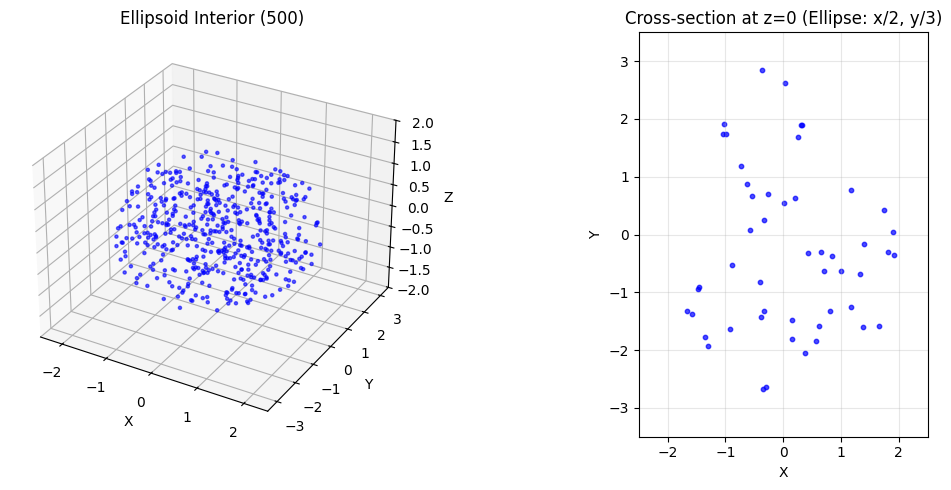

In [22]:
from QSER.Geometry import Geometry
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os


# Define ellipsoid: (x/2)^2 + (y/3)^2 + (z/1.5)^2 < 1
def inside_ellipsoid(x, y, z):
    return (x/2)**2 + (y/3)**2 + (z/1.5)**2 < 1

# Create geometry
geo = Geometry.define(
    inside_func=inside_ellipsoid,
    bounds=(-2.5, 2.5, -3.5, 3.5, -2.0, 2.0)
)

print(f"Bounds: {geo.bounding_box()}")
print(f"Format: {geo._metadata.get('format', 'unknown')}")

# Sample interior (rejection sampling)
interior = geo.sample_points(n_points=500, method='random', seed=42, max_attempts=50000)
print(f"Interior: {interior.shape}")

# Plot
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(interior[:, 0], interior[:, 1], interior[:, 2], c='blue', s=5, alpha=0.6)
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_title(f'Ellipsoid Interior ({len(interior)})')
ax1.set_xlim(-2.5, 2.5); ax1.set_ylim(-3.5, 3.5); ax1.set_zlim(-2.0, 2.0)

# Cross-section at z=0 (should be ellipse: x/2, y/3)
ax2 = fig.add_subplot(122)
mask_z0 = np.abs(interior[:, 2]) < 0.1
ax2.scatter(interior[mask_z0, 0], interior[mask_z0, 1], c='blue', s=10, alpha=0.7)
ax2.set_xlabel('X'); ax2.set_ylabel('Y')
ax2.set_title('Cross-section at z=0 (Ellipse: x/2, y/3)')
ax2.set_xlim(-2.5, 2.5); ax2.set_ylim(-3.5, 3.5)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

plt.tight_layout()

# Save
fig.savefig(os.path.join(FIGURES_DIR, "geometry_ellipsoid.png"), dpi=300, bbox_inches='tight')
print("✅ Figure saved: geometry_ellipsoid.png")
plt.show()

## Testing geometry cylinder

Vertices: 66
Faces: 128
Bounds: (np.float64(-0.5), np.float64(0.5), np.float64(-0.5), np.float64(0.5), np.float64(-1.0), np.float64(1.0))
Volume: 1.5607 (expected: ~1.5708)
Interior: (300, 3)
✅ Figure saved: geometry_cylinder.png


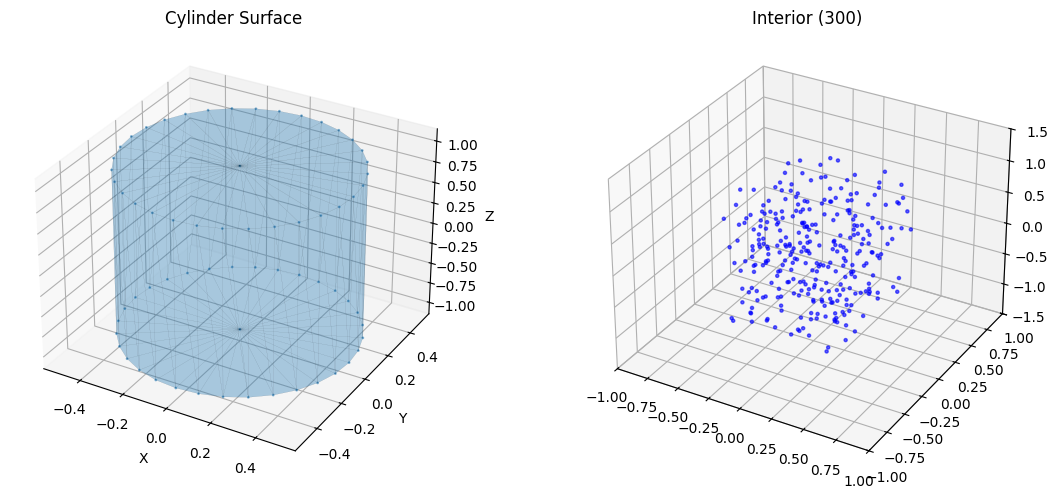

In [23]:
from QSER.Geometry import Geometry
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os


# Create cylinder
geo = Geometry.cylinder(center=(0, 0, 0), radius=0.5, height=2.0)

print(f"Vertices: {geo.n_vertices}")
print(f"Faces: {geo.n_faces}")
print(f"Bounds: {geo.bounding_box()}")
print(f"Volume: {geo.volume():.4f} (expected: ~1.5708)")

# Sample interior
interior = geo.sample_points(n_points=300, method='random', seed=42)
print(f"Interior: {interior.shape}")

# Plot
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
geo.plot(ax=ax1, show_vertices=True, show_faces=True)
ax1.set_title('Cylinder Surface')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(interior[:, 0], interior[:, 1], interior[:, 2], c='blue', s=5, alpha=0.6)
ax2.set_title(f'Interior ({len(interior)})')
ax2.set_xlim(-1.0, 1.0); ax2.set_ylim(-1.0, 1.0); ax2.set_zlim(-1.5, 1.5)

plt.tight_layout()

# Save
fig.savefig(os.path.join(FIGURES_DIR, "geometry_cylinder.png"), dpi=300, bbox_inches='tight')
print("✅ Figure saved: geometry_cylinder.png")
plt.show()

## Testing geometry cube

Vertices: 8
Faces: 12
Bounds: (np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))
Volume: 8.0000 (expected: 8.0)
Interior: (300, 3)
✅ Figure saved: geometry_cube.png


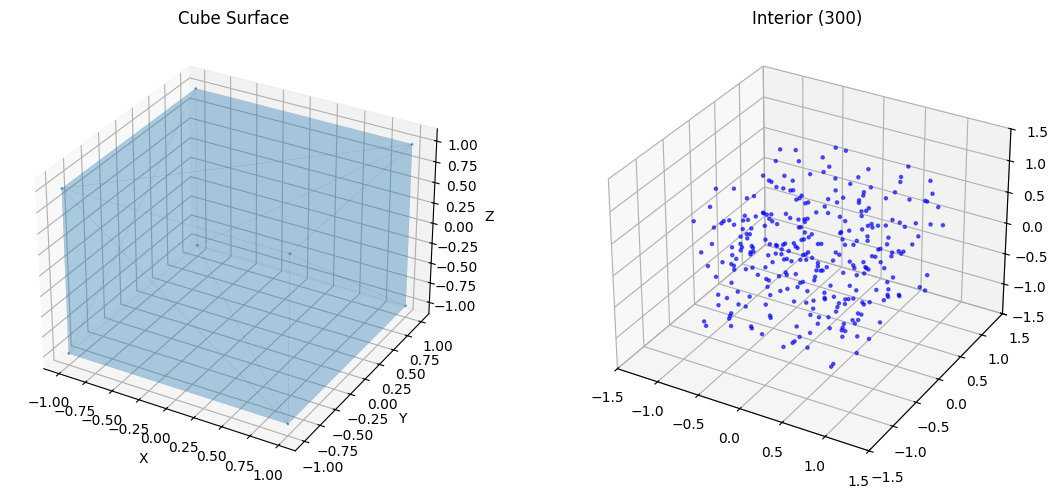

In [24]:
from QSER.Geometry import Geometry
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os

# Figures directory
FIGURES_DIR = "/home/ahmad/Yandex.Disk/Research/Q theory/QSER solver 2026/QSER user guide book/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Create cube
geo = Geometry.cube(center=(0, 0, 0), size=2.0)

print(f"Vertices: {geo.n_vertices}")
print(f"Faces: {geo.n_faces}")
print(f"Bounds: {geo.bounding_box()}")
print(f"Volume: {geo.volume():.4f} (expected: 8.0)")

# Sample interior
interior = geo.sample_points(n_points=300, method='random', seed=42)
print(f"Interior: {interior.shape}")

# Plot
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
geo.plot(ax=ax1, show_vertices=True, show_faces=True)
ax1.set_title('Cube Surface')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(interior[:, 0], interior[:, 1], interior[:, 2], c='blue', s=5, alpha=0.6)
ax2.set_title(f'Interior ({len(interior)})')
ax2.set_xlim(-1.5, 1.5); ax2.set_ylim(-1.5, 1.5); ax2.set_zlim(-1.5, 1.5)

plt.tight_layout()

# Save
fig.savefig(os.path.join(FIGURES_DIR, "geometry_cube.png"), dpi=300, bbox_inches='tight')
print("✅ Figure saved: geometry_cube.png")
plt.show()

## Testing Sphere with plotting only

Vertices: 642
Faces: 1280
Bounds: (np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))
Volume: 4.1527
Interior: (500, 3)


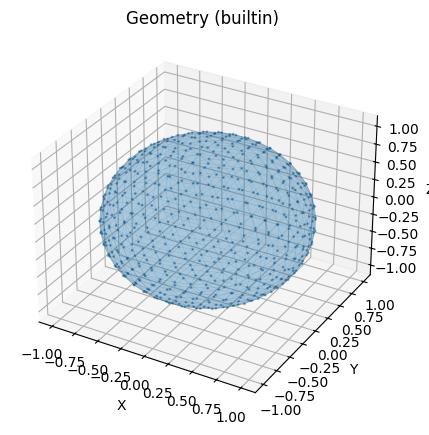

In [25]:

from QSER.Geometry import Geometry
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

geo = Geometry.sphere(radius=1.0, center=(0, 0, 0))
print(f"Vertices: {geo.n_vertices}")
print(f"Faces: {geo.n_faces}")
print(f"Bounds: {geo.bounding_box()}")
print(f"Volume: {geo.volume():.4f}")

interior = geo.sample_points(n_points=500, method='random', seed=42)
print(f"Interior: {interior.shape}")

# Plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')
geo.plot(ax=ax, show_vertices=True, show_faces=True)
plt.show()

✅ Figure saved: sphere_geometry.png


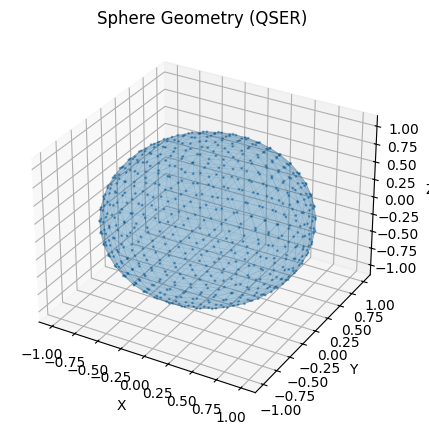

In [26]:
# Save the sphere plot
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(111, projection='3d')
geo.plot(ax=ax, show_vertices=True, show_faces=True)
ax.set_title('Sphere Geometry (QSER)')



## Testing operator classes

In [27]:
from QSER.Mesh import Structured1D
from QSER.Operators import Gradient, Laplacian, Divergence
import numpy as np
import time

print("=" * 70)
print("OPERATORS ENGINE: COMPLETE TEST")
print("=" * 70)

# Create mesh
mesh = Structured1D(nx=100, L=10.0, backend='numpy')
x = mesh.get_cell_centers()
faces = mesh.get_face_centers()

# Create fields
field = np.sin(x)
flux = faces**2

print("\n1. GRADIENT TEST")
print("-" * 40)

grad_op = Gradient(mesh=mesh)
grad_5p = grad_op.compute(field, method='5point')
grad_ls = grad_op.compute(field, method='least_squares')
analytical = np.cos(x)

error_5p = np.max(np.abs(grad_5p[2:-2] - analytical[2:-2]))
error_ls = np.max(np.abs(grad_ls[2:-2] - analytical[2:-2]))

print(f"5-Point error:      {error_5p:.6e}")
print(f"Least-Squares error: {error_ls:.6e}")

print("\n2. LAPLACIAN TEST")
print("-" * 40)

lap_op = Laplacian(mesh=mesh)
lap_5p = lap_op.compute(field, method='5point')
lap_3p = lap_op.compute(field, method='3point')
analytical_lap = -np.sin(x)

error_5p_lap = np.max(np.abs(lap_5p[2:-2] - analytical_lap[2:-2]))
error_3p_lap = np.max(np.abs(lap_3p[2:-2] - analytical_lap[2:-2]))

print(f"5-Point Laplacian error:  {error_5p_lap:.6e}")
print(f"3-Point Laplacian error:  {error_3p_lap:.6e}")

print("\n3. DIVERGENCE TEST")
print("-" * 40)

div_op = Divergence(mesh=mesh)
div = div_op.compute(flux)
analytical_div = 2 * x

error_div = np.max(np.abs(div[2:-2] - analytical_div[2:-2]))
print(f"Divergence error: {error_div:.6e}")

print("\n4. STAND-ALONE OPERATORS (Arbitrary Field)")
print("-" * 40)

x_arb = np.linspace(0, 10, 100)
field_arb = np.sin(x_arb)
dx_arb = x_arb[1] - x_arb[0]

grad_standalone = Gradient(backend='numpy')
grad_arb = grad_standalone.compute(field_arb, dx=dx_arb, axis=0)

lap_standalone = Laplacian(backend='numpy')
lap_arb = lap_standalone.compute(field_arb, dx=dx_arb)

analytical_grad_arb = np.cos(x_arb)
analytical_lap_arb = -np.sin(x_arb)

error_grad_standalone = np.max(np.abs(grad_arb[2:-2] - analytical_grad_arb[2:-2]))
error_lap_standalone = np.max(np.abs(lap_arb[2:-2] - analytical_lap_arb[2:-2]))

print(f"Stand-alone gradient error:   {error_grad_standalone:.6e}")
print(f"Stand-alone Laplacian error:  {error_lap_standalone:.6e}")

print("\n5. BACKEND SWITCHING TEST")
print("-" * 40)

backends = ['numpy', 'torch', 'jax']
for backend in backends:
    try:
        mesh_b = Structured1D(nx=100, L=10.0, backend=backend)
        x_b = mesh_b.get_cell_centers()
        field_b = np.sin(x_b)
        
        grad_op_b = Gradient(mesh=mesh_b)
        start = time.time()
        grad_b = grad_op_b.compute(field_b)
        elapsed = time.time() - start
        
        print(f"{backend:10s}: gradient shape {grad_b.shape}, time {elapsed:.4f}s")
    except Exception as e:
        print(f"{backend:10s}: FAILED - {str(e)}")

print("\n6. GRADIENT METHOD SWITCHING TEST")
print("-" * 40)

grad_op = Gradient(mesh=mesh)
methods = ['5point', 'least_squares']

for method in methods:
    grad = grad_op.compute(field, method=method)
    error = np.max(np.abs(grad[2:-2] - analytical[2:-2]))
    print(f"{method:15s}: error = {error:.6e}")

print("\n" + "=" * 70)
print("✅ OPERATORS ENGINE TEST COMPLETE")
print("=" * 70)

OPERATORS ENGINE: COMPLETE TEST

1. GRADIENT TEST
----------------------------------------
5-Point error:      3.329250e-06
Least-Squares error: 1.665775e-03

2. LAPLACIAN TEST
----------------------------------------
5-Point Laplacian error:  1.110111e-06
3-Point Laplacian error:  8.330490e-04

3. DIVERGENCE TEST
----------------------------------------
Divergence error: 1.101341e-13

4. STAND-ALONE OPERATORS (Arbitrary Field)
----------------------------------------
Stand-alone gradient error:   3.465672e-06
Stand-alone Laplacian error:  1.155281e-06

5. BACKEND SWITCHING TEST
----------------------------------------
numpy     : gradient shape (100,), time 0.0000s
torch     : gradient shape (100,), time 0.0001s
jax       : gradient shape (100,), time 0.0000s

6. GRADIENT METHOD SWITCHING TEST
----------------------------------------
5point         : error = 3.329250e-06
least_squares  : error = 1.665775e-03

✅ OPERATORS ENGINE TEST COMPLETE


## Testing boundary conditions 1D

In [28]:
from QSER.Mesh import Structured1D, Boundary
import numpy as np

mesh = Structured1D(nx=100, L=10.0)
x = mesh.get_cell_centers()

field = np.sin(x)
print(f"field[50]: {field[50]:.6f}")

boundary = Boundary(mesh)
boundary.add_patch('source', [50])
boundary.set_source('source', 2.0)
field_bc = boundary.apply(field)

print(f"field_bc[50]: {field_bc[50]:.6f}")
print(f"field[50] (original): {field[50]:.6f}")
print(f"Difference: {field_bc[50] - field[50]:.6f}")

field[50]: -0.943549
field_bc[50]: 1.056451
field[50] (original): -0.943549
Difference: 2.000000


In [29]:
from QSER.Mesh import Structured1D, Boundary
import numpy as np

print("=" * 70)
print("BOUNDARY ENGINE COMPLETE TEST")
print("=" * 70)

# Create mesh
mesh = Structured1D(nx=100, L=10.0)
x = mesh.get_cell_centers()
field = np.sin(x)

# Create boundary engine
boundary = Boundary(mesh)

print("\n1. DIRICHLET BC")
print("-" * 40)
boundary.clear()
boundary.add_patch('left', [0])
boundary.add_patch('right', [-1])
boundary.set_dirichlet('left', 0.0)
boundary.set_dirichlet('right', 1.0)
field_bc = boundary.apply(field)
print(f"Original: left={field[0]:.6f}, right={field[-1]:.6f}")
print(f"Dirichlet: left={field_bc[0]:.6f}, right={field_bc[-1]:.6f}")

print("\n2. NEUMANN BC")
print("-" * 40)
boundary.clear()
boundary.add_patch('left', [0])
boundary.add_patch('right', [-1])
boundary.set_neumann('left', 0.0)
boundary.set_neumann('right', 0.0)
field_bc = boundary.apply(field)
print(f"Original: left={field[0]:.6f}, right={field[-1]:.6f}")
print(f"Neumann: left={field_bc[0]:.6f}, right={field_bc[-1]:.6f}")

print("\n3. ROBIN BC")
print("-" * 40)
boundary.clear()
boundary.add_patch('left', [0])
boundary.add_patch('right', [-1])
# a*f + b*df/dn = c
# For left: f(0) + 0.5*df/dx = 0 => f = -0.5*df/dx
# For right: f(L) + 0.5*df/dx = 1 => f = 1 - 0.5*df/dx
boundary.set_robin('left', 1.0, 0.5, 0.0)
boundary.set_robin('right', 1.0, 0.5, 1.0)
field_bc = boundary.apply(field)
print(f"Original: left={field[0]:.6f}, right={field[-1]:.6f}")
print(f"Robin: left={field_bc[0]:.6f}, right={field_bc[-1]:.6f}")

print("\n4. PERIODIC BC")
print("-" * 40)
# Create a periodic field (sine wave)
field_periodic = np.sin(2 * np.pi * x / 10.0)
boundary.clear()
boundary.add_patch('left', [0])
boundary.add_patch('right', [-1])
boundary.set_periodic('left', match_patch='right')
field_bc = boundary.apply(field_periodic)
print(f"Original: left={field_periodic[0]:.6f}, right={field_periodic[-1]:.6f}")
print(f"Periodic: left={field_bc[0]:.6f}, right={field_bc[-1]:.6f}")
print(f"Difference: {field_bc[0] - field_bc[-1]:.6e} (should be near 0)")

print("\n5. WALL BC (No-Slip)")
print("-" * 40)
# Wall BC sets value to 0 at wall (no-slip)
boundary.clear()
boundary.add_patch('left', [0])
boundary.add_patch('right', [-1])
boundary.set_wall('left', wall_type='no-slip')
boundary.set_wall('right', wall_type='no-slip')
field_bc = boundary.apply(field)
print(f"Original: left={field[0]:.6f}, right={field[-1]:.6f}")
print(f"No-Slip Wall: left={field_bc[0]:.6f}, right={field_bc[-1]:.6f}")

print("\n6. WALL BC (Free-Slip)")
print("-" * 40)
boundary.clear()
boundary.add_patch('left', [0])
boundary.add_patch('right', [-1])
boundary.set_wall('left', wall_type='free-slip')
boundary.set_wall('right', wall_type='free-slip')
field_bc = boundary.apply(field)
print(f"Original: left={field[0]:.6f}, right={field[-1]:.6f}")
print(f"Free-Slip Wall: left={field_bc[0]:.6f}, right={field_bc[-1]:.6f}")

print("\n7. SOURCE TERM")
print("-" * 40)
# Add a source at the center (index 50)
boundary.clear()
boundary.add_patch('source', [50])
boundary.set_source('source', 5.0)
field_bc = boundary.apply(field)
print(f"Original at center: {field[50]:.6f}")
print(f"With Source at center: {field_bc[50]:.6f}")
print(f"Difference: {field_bc[50] - field[50]:.6f}")

print("\n8. CUSTOM BC")
print("-" * 40)
def custom_bc(field, mesh, indices, time):
    # Set left boundary to 2.0
    field[0] = 2.0
    # Set right boundary to -2.0
    field[-1] = -2.0
    return field

boundary.clear()
boundary.add_patch('left', [0])
boundary.add_patch('right', [-1])
boundary.set_custom('left', custom_bc)
boundary.set_custom('right', custom_bc)
field_bc = boundary.apply(field)
print(f"Original: left={field[0]:.6f}, right={field[-1]:.6f}")
print(f"Custom: left={field_bc[0]:.6f}, right={field_bc[-1]:.6f}")

print("\n9. MULTIPLE PATCHES (Complex Geometry)")
print("-" * 40)
# Multiple patches with different BCs
boundary.clear()
boundary.add_patch('inlet', [0, 1, 2])          # First 3 cells
boundary.add_patch('outlet', [-1])               # Last cell
boundary.add_patch('wall', [10, 11, 12])        # Cells 10-12
boundary.add_patch('source_region', [50, 51, 52]) # Cells 50-52

boundary.set_dirichlet('inlet', 1.0)
boundary.set_neumann('outlet', 0.0)
boundary.set_wall('wall', wall_type='no-slip')
boundary.set_source('source_region', 2.0)

field_bc = boundary.apply(field)
print("Multiple patches applied:")
print(f"  Inlet (cells 0-2): {field_bc[0]:.6f}, {field_bc[1]:.6f}, {field_bc[2]:.6f}")
print(f"  Outlet (cell -1): {field_bc[-1]:.6f}")
print(f"  Wall (cells 10-12): {field_bc[10]:.6f}, {field_bc[11]:.6f}, {field_bc[12]:.6f}")
print(f"  Source (cells 50-52): {field_bc[50]:.6f}, {field_bc[51]:.6f}, {field_bc[52]:.6f}")

print("\n10. GET CONDITIONS")
print("-" * 40)
conditions = boundary.get_conditions()
for patch, cond in conditions.items():
    print(f"  {patch}: {cond}")

print("\n" + "=" * 70)
print("✅ ALL BOUNDARY CONDITIONS TESTED")
print("=" * 70)

BOUNDARY ENGINE COMPLETE TEST

1. DIRICHLET BC
----------------------------------------
Original: left=0.049979, right=-0.501405
Dirichlet: left=0.000000, right=1.000000

2. NEUMANN BC
----------------------------------------
Original: left=0.049979, right=-0.501405
Neumann: left=0.149438, right=-0.131542

3. ROBIN BC
----------------------------------------
Original: left=0.049979, right=-0.501405
Robin: left=0.124532, right=0.046670

4. PERIODIC BC
----------------------------------------
Original: left=0.031411, right=-0.031411
Periodic: left=-0.000000, right=-0.000000
Difference: 0.000000e+00 (should be near 0)

5. WALL BC (No-Slip)
----------------------------------------
Original: left=0.049979, right=-0.501405
No-Slip Wall: left=0.000000, right=0.000000

6. WALL BC (Free-Slip)
----------------------------------------
Original: left=0.049979, right=-0.501405
Free-Slip Wall: left=0.149438, right=-0.131542

7. SOURCE TERM
----------------------------------------
Original at center:

In [30]:
from QSER.Mesh import Structured1D, Boundary
import numpy as np

mesh = Structured1D(nx=100, L=10.0)
x = mesh.get_cell_centers()

field = np.sin(x)
print(f"field[50]: {field[50]:.6f}")

boundary = Boundary(mesh)
boundary.add_patch('source', [50])
boundary.set_source('source', 2.0)
field_bc = boundary.apply(field)

print(f"field_bc[50]: {field_bc[50]:.6f}")

# Compare
diff = field_bc[50] - field[50]
print(f"Difference: {diff:.6f}")

field[50]: -0.943549
field_bc[50]: 1.056451
Difference: 2.000000


### Testing Mesh Quality

In [31]:
from QSER.Mesh import Structured1D
from QSER.Mesh.quality import MeshQuality
import numpy as np

print("✅ Import successful")

mesh = Structured1D(nx=100, L=10.0)
quality = MeshQuality(mesh)

orthogonality = quality.compute_orthogonality()
skewness = quality.compute_skewness()
aspect_ratio = quality.compute_aspect_ratio()
volumes = quality.compute_cell_volumes()

print(f"Orthogonality: min={orthogonality.min():.4f}, max={orthogonality.max():.4f}")
print(f"Skewness: min={skewness.min():.4f}, max={skewness.max():.4f}")
print(f"Aspect Ratio: min={aspect_ratio.min():.4f}, max={aspect_ratio.max():.4f}")
print(f"Volumes: min={volumes.min():.4f}, max={volumes.max():.4f}")

report = quality.report()
print("\nQuality Report:")
for key, value in report.items():
    if isinstance(value, dict):
        print(f"  {key}:")
        for k, v in value.items():
            print(f"    {k}: {v}")
    else:
        print(f"  {key}: {value}")

✅ Import successful
Orthogonality: min=1.0000, max=1.0000
Skewness: min=0.0000, max=0.0000
Aspect Ratio: min=1.0000, max=1.0000
Volumes: min=0.1000, max=0.1000

Quality Report:
  orthogonality:
    min: 1.0
    max: 1.0
    avg: 1.0
    std: 0.0
  skewness:
    min: 0.0
    max: 8.881784197001205e-15
    avg: 2.396693954409552e-15
    std: 2.7076879916867988e-15
  aspect_ratio:
    min: 1.0
    max: 1.0
    avg: 1.0
    std: 0.0
  cell_volume:
    min: 0.09999999999999964
    max: 0.10000000000000142
    avg: 0.1
    std: 4.293600054461829e-16
  has_negative_volume: False
  is_valid: True
  recommendation: Excellent quality


# Backend Switching 1D

In [32]:
from QSER.Mesh import Structured1D
import numpy as np
import time


# Test different backends
backends = ['numpy', 'torch', 'jax']
results = {}

for backend in backends:
    print(f"\n--- Backend: {backend} ---")
    
    # Create mesh with specified backend
    mesh = Structured1D(nx=1000, L=10.0, backend=backend)
    x = mesh.get_cell_centers()
    
    # Create field
    field = np.sin(x)
    
    # Compute gradient
    start = time.time()
    grad = mesh.compute_gradient(field)
    elapsed = time.time() - start
    
    print(f"Gradient computed in {elapsed:.4f}s")
    print(f"Backend type: {type(grad)}")


--- Backend: numpy ---
Gradient computed in 0.0087s
Backend type: <class 'numpy.ndarray'>

--- Backend: torch ---
Gradient computed in 0.0149s
Backend type: <class 'numpy.ndarray'>

--- Backend: jax ---
Gradient computed in 0.2577s
Backend type: <class 'numpy.ndarray'>


# Interpolating faces test

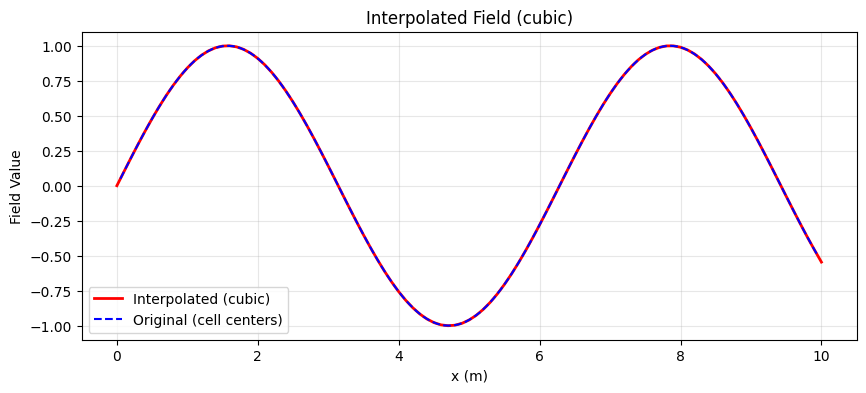

In [33]:
from QSER.Mesh import Structured1D
import numpy as np

# Create mesh
mesh = Structured1D(nx=100, L=10.0)
x = mesh.get_cell_centers()
faces = mesh.get_face_centers()

# Create field at cell centers
field = np.sin(x)

# Interpolate to faces
intfield = mesh.interpolate_to_faces(field, method="cubic")

# Plot the interpolated field by creating a figure manually
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(faces, intfield, 'r-', linewidth=2, label='Interpolated (cubic)')
ax.plot(x, field, 'b--', linewidth=1.5, label='Original (cell centers)')
ax.set_xlabel('x (m)')
ax.set_ylabel('Field Value')
ax.set_title('Interpolated Field (cubic)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Plotting 1d test

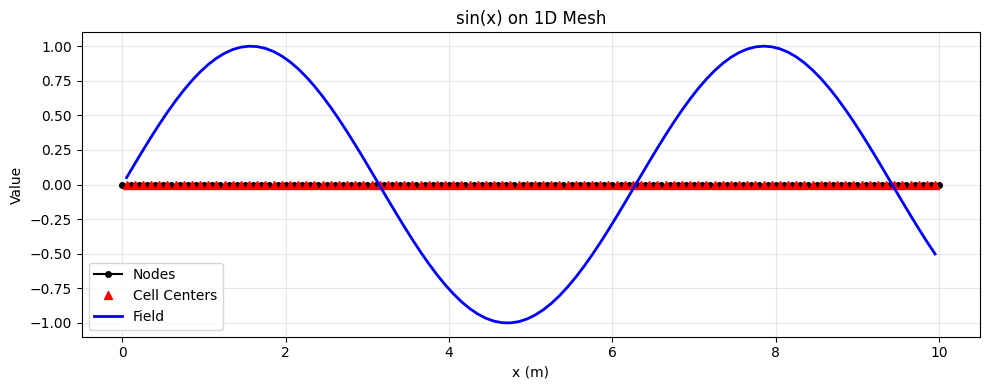

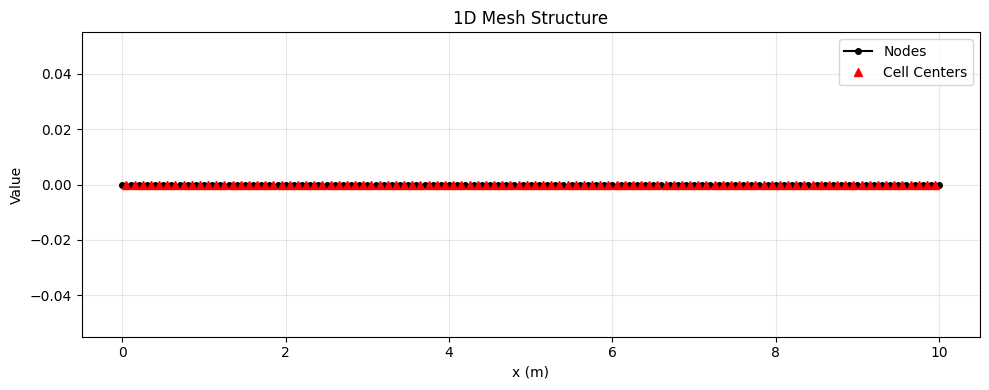

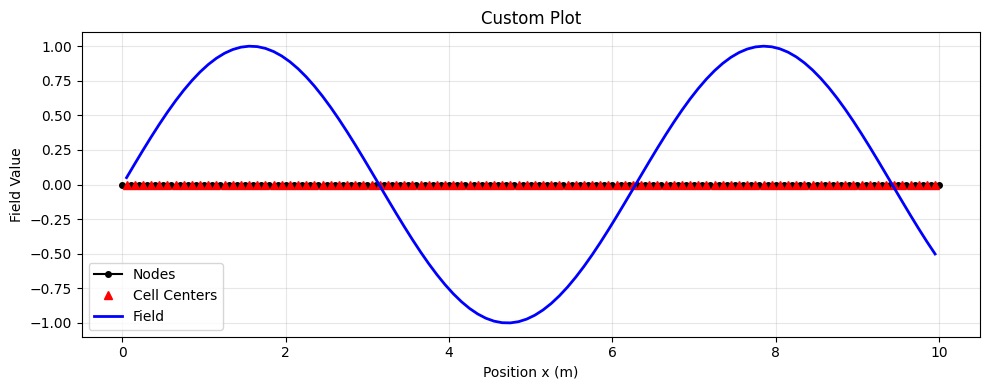

In [34]:
from QSER.Mesh import Structured1D
import numpy as np

# Create mesh
mesh = Structured1D(nx=100, L=10.0)
x = mesh.get_cell_centers()

# Create field
field = np.sin(x)

# Plot field
mesh.plot(field, title="sin(x) on 1D Mesh")

# Plot mesh only (no field)
mesh.plot(title="1D Mesh Structure")

# Return figure for customization
fig, ax = mesh.plot(field, title="Custom Plot", return_fig=True)
ax.set_xlabel('Position x (m)')
ax.set_ylabel('Field Value')
fig.savefig('my_plot.png')



### Boundary Conditions test on 1D

In [35]:
from QSER.Mesh import Structured1D
import numpy as np

# Create mesh
mesh = Structured1D(nx=100, L=10.0)
x = mesh.get_cell_centers()

# Create field
field = np.sin(x)

# Apply Dirichlet boundary conditions (fixed values)
field_dirichlet = mesh.apply_bc(field, 'dirichlet', [0.0, 1.0])
print(f"Dirichlet: left={field_dirichlet[0]:.6f}, right={field_dirichlet[-1]:.6f}")

# Apply Neumann boundary conditions (fixed gradients)
field_neumann = mesh.apply_bc(field, 'neumann', [0.0, 0.0])
print(f"Neumann: left={field_neumann[0]:.6f}, right={field_neumann[-1]:.6f}")

# Compare with original
print(f"\nOriginal: left={field[0]:.6f}, right={field[-1]:.6f}")

Dirichlet: left=0.000000, right=1.000000
Neumann: left=0.149438, right=-0.412523

Original: left=0.149438, right=-0.412523


### Interpolation Methods on 1D

In [36]:
from QSER.Mesh import Structured1D
import numpy as np

# Create mesh
mesh = Structured1D(nx=100, L=10.0)
x = mesh.get_cell_centers()
faces = mesh.get_face_centers()

# Create field at cell centers
field = np.sin(x)

# Test all interpolation methods
methods = ['linear', 'nearest', 'cubic', 'pchip', 'savgol']

for method in methods:
    field_faces = mesh.interpolate_to_faces(field, method=method)
    analytical = np.sin(faces)
    error = np.max(np.abs(field_faces - analytical))
    print(f"{method:10s}: error = {error:.6e}")

# See available methods
print(f"\nAvailable: {mesh.available_interpolation_methods()}")

linear    : error = 4.997917e-02
nearest   : error = 4.999479e-02
cubic     : error = 1.482971e-03
pchip     : error = 9.708522e-04
savgol    : error = 4.983288e-02

Available: ['linear', 'nearest', 'cubic', 'pchip', 'savgol']


## Divergence Computation 1D

In [37]:
from QSER.Mesh import Structured1D
import numpy as np

# Create mesh
mesh = Structured1D(nx=100, L=10.0)
x = mesh.get_cell_centers()
faces = mesh.get_face_centers()

# Create flux field at faces (F(x) = x²)
flux = faces**2

# Compute divergence
div = mesh.compute_divergence(flux)

# Analytical divergence: d/dx(x²) = 2x
analytical = 2 * x

# Check error (interior only)
interior = slice(2, -2)
error = np.max(np.abs(div[interior] - analytical[interior]))

print(f"Divergence error: {error:.6e}")

Divergence error: 1.101341e-13


## Laplacian Computation 1D

In [38]:
from QSER.Mesh import Structured1D
import numpy as np

# Create mesh
mesh = Structured1D(nx=100, L=10.0)
x = mesh.get_cell_centers()

# Create field
field = np.sin(x)

# Compute Laplacian
lap = mesh.compute_laplacian(field)

# Analytical Laplacian: d²/dx² sin(x) = -sin(x)
analytical = -np.sin(x)

# Check error (interior only)
interior = slice(2, -2)
error = np.max(np.abs(lap[interior] - analytical[interior]))

print(f"Laplacian error: {error:.6e}")

Laplacian error: 1.110111e-06


## Gradient Method Switching 1D

In [39]:
from QSER.Mesh import Structured1D
import numpy as np

mesh = Structured1D(nx=100, L=10.0)
x = mesh.get_cell_centers()
field = np.sin(x)

grad = mesh.compute_gradient(field)

mesh.set_gradient_method('5point')
grad_5p = mesh.compute_gradient(field)

grad_ls = mesh.compute_gradient(field, method='least_squares')

analytical = np.cos(x)

interior = slice(2, -2)
error_ls = np.max(np.abs(grad_ls[interior] - analytical[interior]))
error_5p = np.max(np.abs(grad_5p[interior] - analytical[interior]))

print(f"Least-Squares error: {error_ls:.6e}")
print(f"5-Point error:       {error_5p:.6e}")

print(f"Available methods: {mesh.available_gradient_methods()}")

Least-Squares error: 1.665775e-03
5-Point error:       3.329250e-06
Available methods: ['5point', 'least_squares', 'green_gauss_node', 'green_gauss_cell', 'pointLinear', 'spectral']


## 1D gradient computation

In [40]:
from QSER.Mesh import Structured1D
import numpy as np

# Create mesh
mesh = Structured1D(nx=100, L=10.0)
x = mesh.get_cell_centers()

# Create field
field = np.sin(x)

# Compute gradient
grad = mesh.compute_gradient(field)

# Compare with analytical derivative
analytical = np.cos(x)

# Check error (interior only)
interior = slice(2, -2)
error = np.max(np.abs(grad[interior] - analytical[interior]))

print(f"Gradient error: {error:.6e}")

Gradient error: 1.665775e-03


## testing 1D Geometry Access

In [41]:
from QSER.Mesh import Structured1D
import numpy as np

# Create mesh
mesh = Structured1D(nx=100, L=10.0)

# Get cell centers
x = mesh.get_cell_centers()
print(x.shape)        # (100,)
print(x[:5])          # First 5 cell centers

# Get cell volumes
volumes = mesh.get_cell_volumes()
print(volumes.shape)  # (100,)
print(volumes[:5])    # First 5 cell volumes

# Get face centers
faces = mesh.get_face_centers()
print(faces.shape)    # (101,)
print(faces[:5])      # First 5 face centers

(100,)
[0.05 0.15 0.25 0.35 0.45]
(100,)
[0.1 0.1 0.1 0.1 0.1]
(101,)
[0.  0.1 0.2 0.3 0.4]


### testing 1D mesh

In [42]:
from QSER.Mesh import Structured1D

# Uniform grid
mesh = Structured1D(nx=100, L=10.0)

# Non-uniform grid (quadratic spacing)
mesh = Structured1D(nx=100, L=10.0, uniform=False)

# Custom coordinates
import numpy as np
x = np.linspace(0, 10, 101)**2 / 10
mesh = Structured1D(x=x)

# Check mesh properties
print(mesh.n_cells)   # Number of cells
print(mesh.n_nodes)   # Number of nodes
print(mesh.n_faces)   # Number of faces
print(mesh.L)         # Domain length

100
101
101
10.0
